## **Configuración**

En esta sección vamos a configurar el ambiente de cómputo requerido para realizar el análisis de esta parte. La configuración involucra el uso de lenguajes de programación Shell y R contenidos en este Notebook.

Primero, vamos a crear una función llamada shell_call para ejecutar scripts de shell directamente.

Seguido de eso, vamos a instalar y configurar R para asegurarnos de que esté listo para usar.

**R** es un lenguaje de programación y ambiente de software para análisis de datos, estadística, y generación de gráficos. Es ampliamente utilizado en investigación cientígica, aprendizaje de máquina, bioinformática, y ciencia de datos debido a su flexibilidad y vasta colección de paquetes. R es un software de código abierto y ofrece herramientas para manipulación de datos, modelamiento estadístico, visualización, e integración con otros lenguajes como Python y C++.

In [ ]:
# Tutorial original: https://stackoverflow.com/questions/70025153/how-to-access-the-shell-in-google-colab-when-running-the-r-kernel
shell_call <- function(command, ...) {
  result <- system(command, intern = TRUE, ...)
  cat(paste0(result, collapse = "\n"))
}

loadPackages = function(pkgs){
  myrequire = function(...){
    suppressWarnings(suppressMessages(suppressPackageStartupMessages(require(...))))
  }
  ok = sapply(pkgs, require, character.only=TRUE, quietly=TRUE)
  if (!all(ok)){
    message("There are missing packages: ", paste(pkgs[!ok], collapse=", "))
  }
}

# Configure R2U para el Ubuntu Jammy

download.file("https://github.com/eddelbuettel/r2u/raw/master/inst/scripts/add_cranapt_jammy.sh",
              "add_cranapt_jammy.sh")
Sys.chmod("add_cranapt_jammy.sh", "0755")
shell_call("./add_cranapt_jammy.sh")
bspm::enable()
options(bspm.version.check=FALSE)
shell_call("rm add_cranapt_jammy.sh")


# Instalación de paquetes necesarios 
cranPkgs2Install = c("BiocManager", "ggpubr", "Seurat", "cowplot",
                     "Rtsne", "hdf5r", "clustree", "SoupX")

install.packages(cranPkgs2Install, ask=FALSE, update=TRUE, quietly=TRUE)

biocPkgs2Install = c("clusterProfiler", "preprocessCore", "rols",
                     "scDblFinder","clusterExperiment", "SingleR",
                     "celldex", "org.Hs.eg.db", "DropletUtils",
                     "miloR", "scran", "scater")
BiocManager::install(biocPkgs2Install, ask=FALSE, update=TRUE, quietly=TRUE)

#### Paquetes en R

**Paquetes en R**

Un paquete en R es una colección de funciones, datos, y documendación agrupados. Los paquetes ayudan a extender la funcionalidad principal de R al proveer herramientas específicas para diferentes tareas, como análisis de datos, visualización de gráficos, estadística avanzada, etc.


**Instalar**

Antes de usar un paquete, debemos instalarlo en el ambiente de trabajo. Esto se debe hacer sólo una vez (a menos que necesite ser actualizado) con el siguiente comando:

In [ ]:
install.packages("nombre_del_paquete")

**LLibrería (Library)**

Una vez instalado, el paquete necesita ser cargado en cada sesión en la cual desea usarse.
El comando revisa si el paquete en cuestión está instalado. Si el paquete está instalado, este es cargado y queda listo para su uso. Si el paquete no está instalado, R devuelve un error.

Así es como la función `library()` entra en uso:

In [ ]:
library(nombre_del_paquete)

In [ ]:
# Para simplificar la carga de paquetes, creamos la función loadPackages().
# Pero, si no necesitas tener esta función, debes usar 'library(nombre_del_paquete)'

pkgs = c("Rtsne", "Seurat", "tidyverse", "cowplot",
         "scDblFinder", "clustree", "preprocessCore",
         "clusterProfiler", "celldex", "SoupX",
          "DropletUtils", "miloR", "scran", "scater")
loadPackages(pkgs)

De esta forma, se han cargado las librerías que instalamos previamente.

* [**Rtsne:**](https://jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf) Paquete de R que implementa la técnica de t-SNA para reducción de dimensionalidad y visualización de datos.
* [**Seurat:**](https://satijalab.org/seurat/articles/get_started.html) Seurat es un paquete de R diseñado para control de calidad (quality control; QC), analisis, y exportación de datos de scRNA-seq.
* [**scDblFinder:**](https://bioconductor.org/packages/release/bioc/html/scDblFinder.html) El paquete scDblFinder recopila varios métodos para la detección y manejo de dobletes/multipletes en datos de secuenciación de célula única (múltiples células capturadas en una sola gota o volumnen de reacción)
* [**Cowplot:**](https://wilkelab.org/cowplot/articles/introduction.html) Provee varias característisticas que ayudan con la creación de figuras con calidad para publicación utilizando [`ggplot2`](https://ggplot2.tidyverse.org/index.html), como un set de temas, funciones para alinear gráficos y ordenarlos en figuras compuestas de alta complejidad, y funciones que facilitan la anotación de gráficos y/o mezclar gráficos e imágenes.
* [**clustree:**](https://lazappi.github.io/clustree/) Este visualizador muestra las relaciones entre agrupaciones de células (clusters) en resoluciones múltiples, permitiendo ver cómo las muestras se muecen mientras el número de clusters crece.
* [**PreprocessCore:**](https://bioconductor.org/packages/release/bioc/html/preprocessCore.html)  Una colección de funciones de pre-procesamiento.

## Entrada de datos, matriz dispersa de conteo de UMI

Artículo Original: https://www.nature.com/articles/s41591-020-0901-9

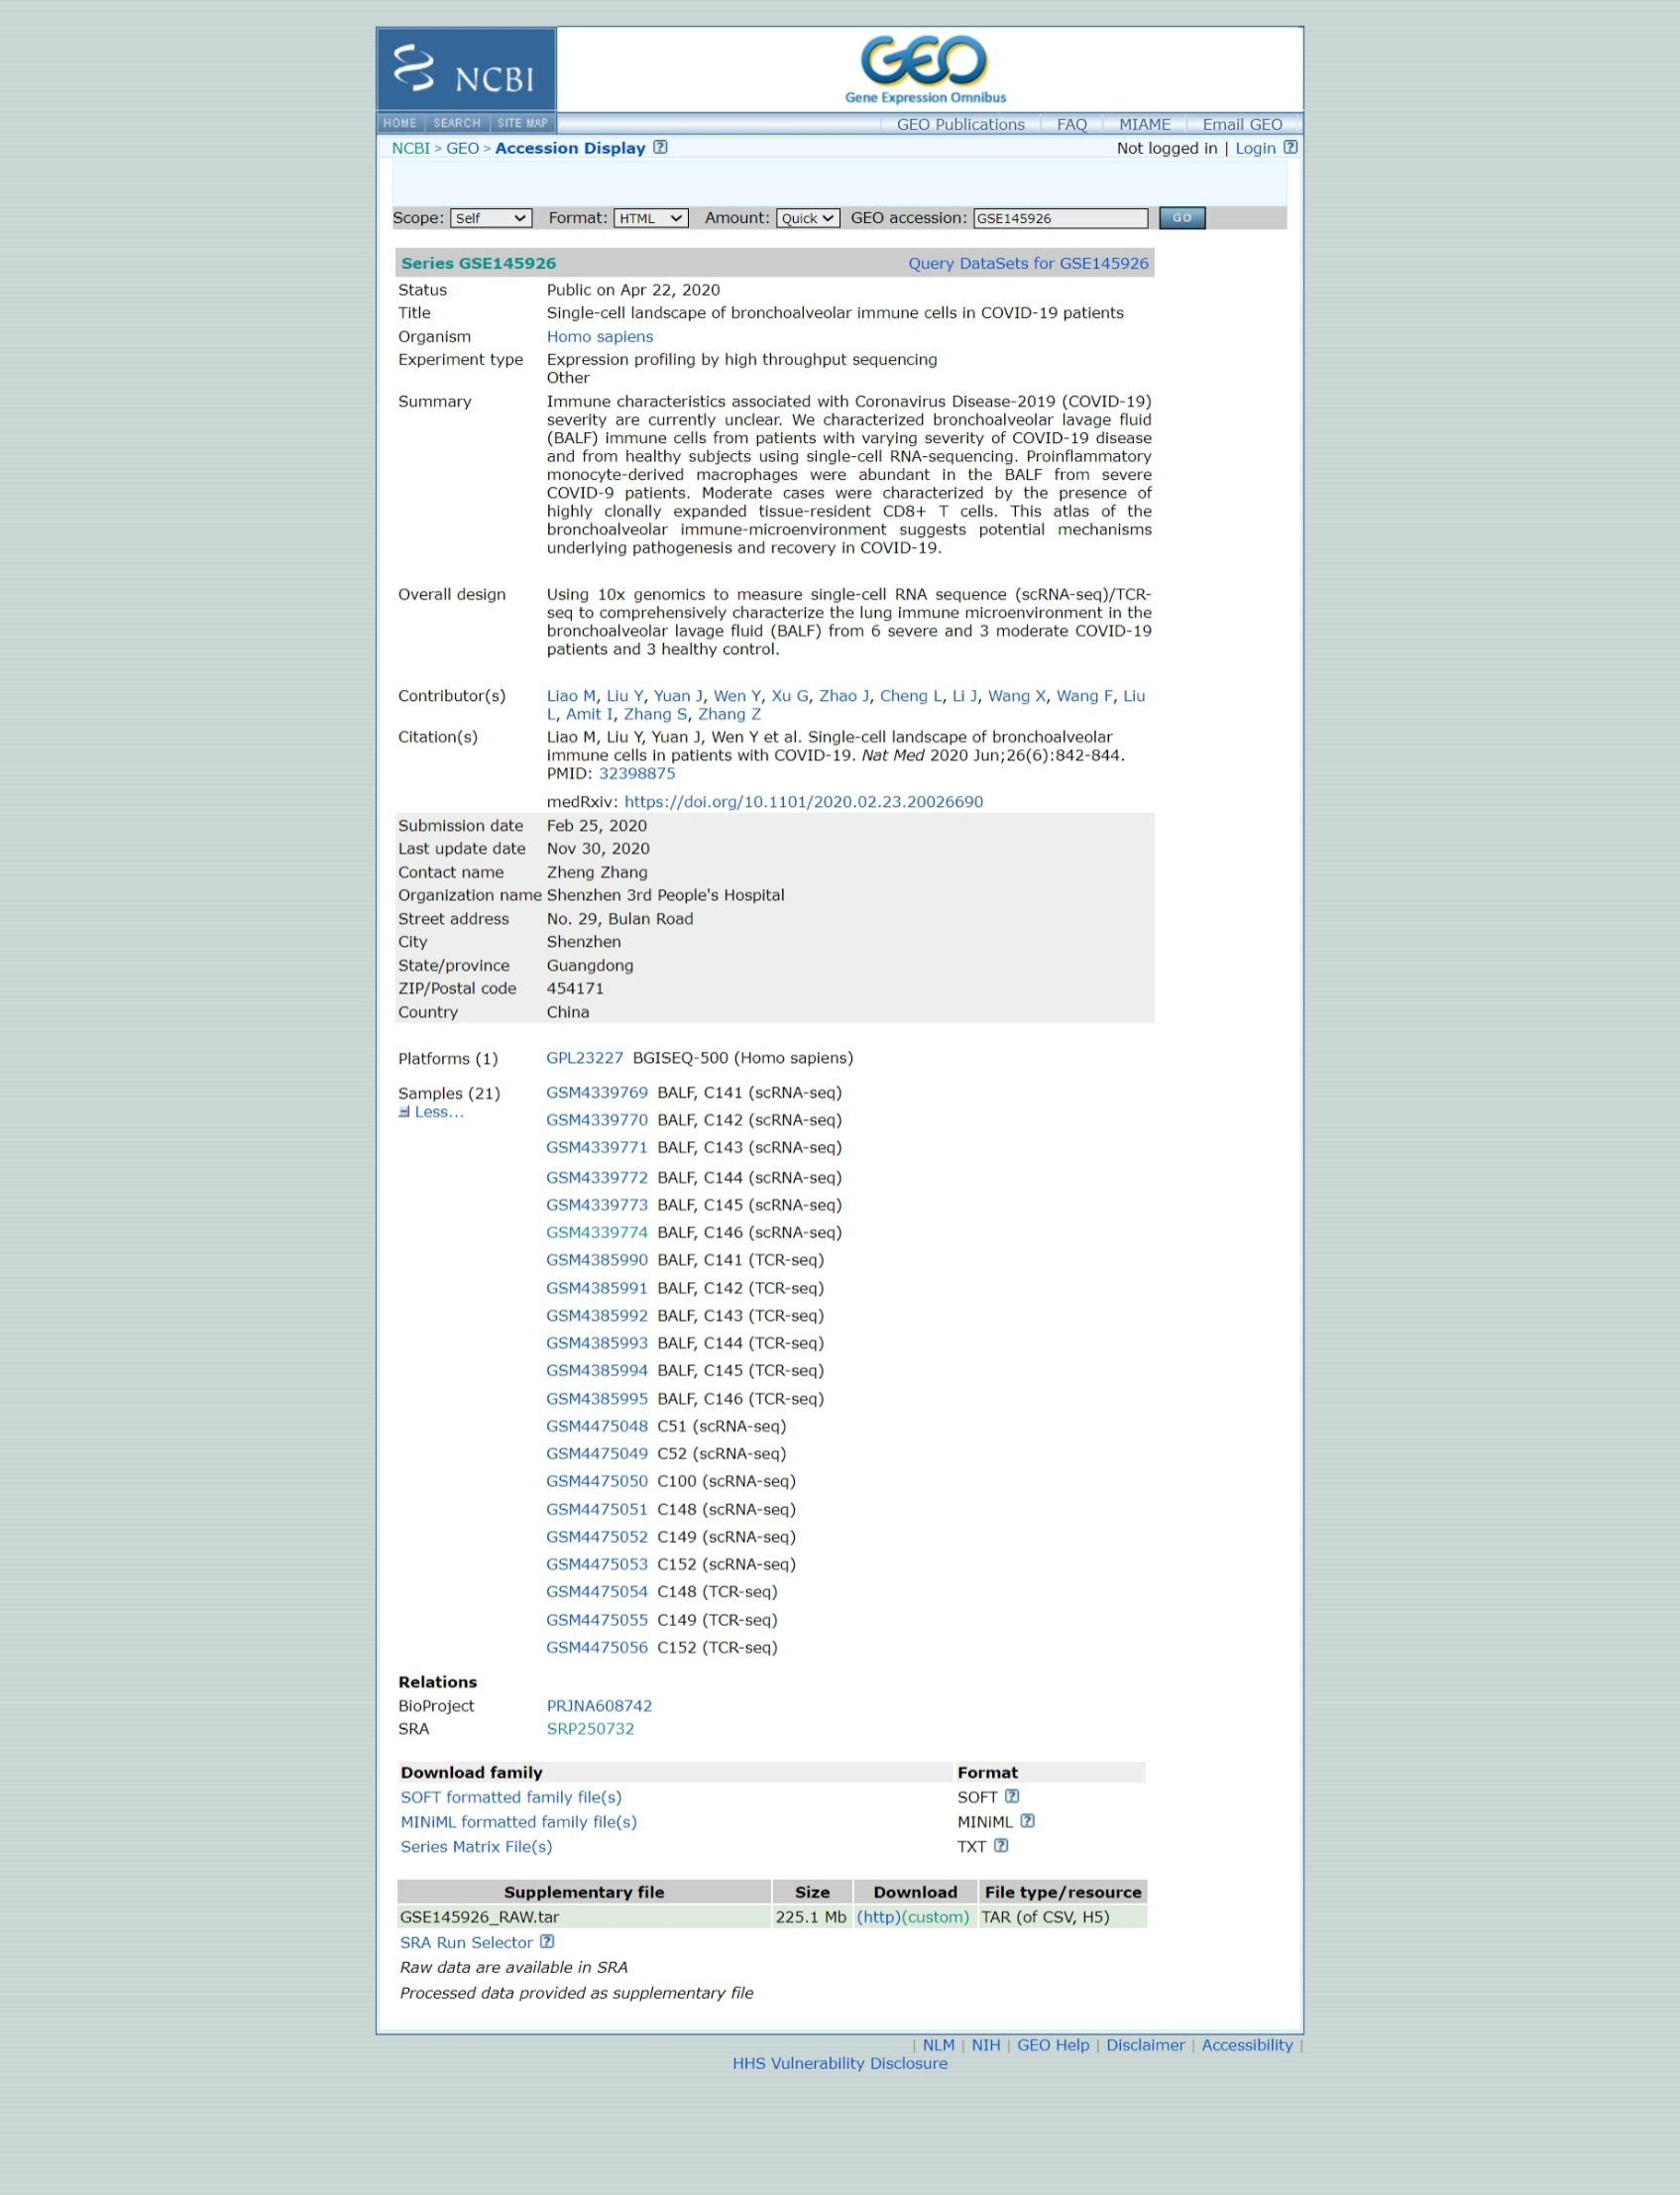

Descargar los datos crudos desde GEO

In [ ]:
# Este comando de R descarga un archivo de internet y lo guarda como archivo local
download.file('https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE145926&format=file','GSE145926_RAW.tar')

# Este comando usa la función personalizada shell_call para ejecutar un comando de shell.
# El comando tar -xf es usado para extraer el contenido de un archivo comprimido en formato .tar.
shell_call("tar -xf GSE145926_RAW.tar")

# rm es un comando de shell para borrar archivos, para liberar espacio y mantener el directorio organizado.
shell_call("rm GSE145926_RAW.tar")

# ls es usado para listar los archivos en un directorio.
# -l: Muestra los detalles de los archivos (permisos, propietario, tamaño, fecha, etc.).
# -h: Formatea el tamaño de los arvhicos a un formato que pueda leer un humano, como KB, MB, o GB.
shell_call("ls -lh")

Separar los archivos de scRNA y TCRseq.

In [ ]:
# Crear un directorio
shell_call("mkdir -p TCRseq")

# mv es el comando de shell para mover o renombrar archivos.
# El patrón *_filtered_contig_annotations.csv.gz usa el caracter comodín "*" para encontrar todos los arvhivos que terminen con "_filtered_contig_annotations.csv.gz".
shell_call("mv *_filtered_contig_annotations.csv.gz TCRseq/")

shell_call("mkdir -p scRNAseq")

#Este comando mueve todos los archivos que contienen "_filtered_" en su nombre al directorio "scRNAseq/".
shell_call("mv *_filtered_* scRNAseq/")
shell_call("ls -lh")

Ahora vamos a leer los datos para una muestra. Los datos de 10X Genomics usualmente son almacenados en el formato HDF5 (Hierarchical Data Format version 5; formato de datos jerárquivos versión 5), es un formato de archivo diseñado para guardar y organizar largos volúmenes de datos eficientemente, siendo un formato de alto rendimiento científico.

El comando Read10X_h5() permite importar estos datos y cargarlos en R, usando un tipo especial de matriz, la cual tiene una forma eficiente de representar los datos con muchos ceros.

Cómo se crearon estos archivos?

In [5]:
sc <- Read10X_h5("scRNAseq/GSM4339769_C141_filtered_feature_bc_matrix.h5")

In [ ]:
# Notas algo especial en esta matriz?
sc[33493:33500,1:3]

En datos de scRNA-seq, la mayoría de los valores en la matriz son ceros (0), representando genes que no han sido detectados en muchas células. Para manipular esto de forma eficiente, Seurat usa una representación de matriz dispersa cada vez que sea posible.

Las matrices dispersas almacenan sólo los valores diferentes de cero y sus ubicaciones, reduciendo significativamente el uso de memoria y mejorando la velocidad de procesamiento para set de datos como Drop-seq, inDrop, o datos de 10X Genomics.

Por ejemplo, convirtiendo una matriz densa (~1600 MB) a una matriz dispersa reduce su tamaño a menos de 160 MB - una reducción de 10 veces. Esta optimización es crucial cuando se trabaja con set de datos de scRNA-seq de gran escala.

In [ ]:
# Convierte el objeto sc, una matriz dispersa de un set de datos de scRNA-seq, a una matriz densa
dense.size <- object.size(as.matrix(sc))

# Calcula el tamaño del objeto sc sin convertirlo a una matriz densa.
sparse.size <- object.size(sc)

# Entrega el tamaño de ambas matrices en MB
format(dense.size, "MB")
format(sparse.size, "MB")

# Calcula la proporción entre el tamaño de la matríz densa y el tamaño de la matriz dispersa.
dense.size/sparse.size

Usamos los comandos usuales de matriz para manipular una matriz dispersa. A continuación se explica cómo:

Conocer las dimenciones de la matriz;
Identificar la clase de una matriz dispersal;
Seleccionar filas y columnas de una matriz dispersa usando índices numéricos;
Extraer los nombres de las columnas (o filas);
Seleccionar filas (o columnas) de una matriz dispersa usando los nombres de las filas (o columnas)

In [ ]:
# Cuántas características?
# Cuántas células?
dim(sc)

# Cuál es la clase: matriz dispersa
class(sc)

# Seleccionar algunas filas y algunas columnas
# Notas algo especial en esta matriz?
sc[33495:33500,1:3]

# Selecciona los nombres de las filas usando 'rownames' (o 'colnames')
sc[c("MIR1302-2HG","FAM138A","OR4F5"), 1:30]

# Cuáles son los nombres de los genes?
rownames(sc)[1:3]

# Extrae el nombre de las células
colnames(sc)[1:3]

Qué tan grande es esta tabla de cuentas?

In [ ]:
# Muestra las dimensiones de sc
print(dim(sc))

# Muestra la clase de sc
print(class(sc))

## Control de calidad (Quality Control - QC)

Ahora crearemos un objeto de Seurat para continuar con el análisis. En este paso, aplicaremos algunos filtros:

1. Remover genes que hayan sido detectados en menos de 3 células
2. Remover células que hayan expresado menos de 200 genes

Estos pasos de filtrado ayudan a limpiar la información al excluir genes y células con expresiones mínimas, las cuáles no serían informativas. Sin embargo, estos filtros son opcionales - uno puede ajustar los límites o saltarse este paso por completo si así se prefiere.

In [10]:
sampleA <- CreateSeuratObject(counts = sc, project="sampleA", min.cells=3, min.features=200)

In [ ]:
# Métricas de control de calidad (QC) para las primeras 5 células
head(sampleA@meta.data, 5)

Qué es lo que sabemos sobre el objeto "sampleA"?

Cuántos genes y cuántas células tiene este objeto Seurat?

Además, por qué estos números son diferentes?

Recuerda que hemos creado el objeto Seurat especificando que cada gen tiene que estar presente en al menos 3 células (de lo contrario el gen será removido). De la misma forma, especificamos que cada célula debe tener al menos 200 genes expresados.

In [ ]:
sampleA

In [ ]:
# Revisemos las dimensiones de la matriz original (sc)
# y comparemos con el objeto Seurat (sampleA)
dim(sc)
dim(sampleA)
dim(sc) - dim(sampleA)

Cuál es el tamaño de nuestro objeto Seurat?
Cuántos genes y células fueron eliminados de la tabla original?

### Identificación de dobletes

Los dobletes (Doublets) ocurren cuando dos o más células son capturadas por error en el mismo pocillo, lo cual es un problema común en la secuenciación de ARN de célula única. Esto puede suceder cuando la suspensión celular está demasiado concentrada.

Para abordar este problema, utilizaremos el método `scDblFinder` para identificar y eliminar los dobletes de nuestro conjunto de datos. Este método requiere un objeto de clase `SingleCellExperimen`t, que forma parte de la infraestructura de Bioconductor.

Pasos:
1. Preparar el objeto `SingleCellExperiment`: Esto es necesario antes de aplicar el método `scDblFinder`.
2. Aplicar `scDblFinder`: El método utiliza un enfoque probabilístico para detectar dobletes, por lo que los resultados pueden variar ligeramente entre ejecuciones.
3. Asegurar la reproducibilidad: Para evitar la variabilidad en los resultados, estableceremos una semilla aleatoria usando la función `set.seed()`. Esto garantiza que el método produzca los mismos resultados cada vez que se ejecute.

Al establecer la semilla, hacemos que el proceso sea reproducible, lo que ayuda a confirmar que los resultados sean consistentes en diferentes ejecuciones.

In [ ]:
sce <- as.SingleCellExperiment(sampleA)
sce

# Necesitamos usar set.seed() porque el comando scDblFinder utiliza una estrategia probabilística para identificar dobles.
# Esto significa que, cada vez que ejecutamos el comando, producirá resultados ligeramente diferentes.
# El comando set.seed() garantizará que se obtengan los mismos resultados cada vez.

set.seed(123)
results <- scDblFinder(sce, returnType = 'table') %>%
  as.data.frame() %>%
  filter(type == 'real')
head(results)

Ten en cuenta que la tabla de resultados incluye una columna llamada "class", la cual categoriza las células en dos tipos: singlete y doblete (singlet y doublet). Como se muestra a continuación, las células dobletes son las cuales deberían ser removidas del set de datos antes de proceder con los análisis posteriores. En otras palabras, queremos conservar sólamente las células etiquetadas como singletes, que representan células individuales, y remover los dobletes.

In [ ]:
results %>%
  dplyr::count(class)

Guardar los resultados de scDblFinder() para usarlos nuevamente después

In [16]:
# Esta función se utiliza para crear una ruta de archivo de manera robusta, independiente del sistema operativo (funciona en Windows, Linux, etc.).
outfile = file.path('dataset1_control.txt')

# Esta función escribe los datos de un data frame o matriz en un archivo de texto.
write.table(results, outfile, sep='\t', quote=F,
            col.names=TRUE, row.names=TRUE)

Vamos a identificar los dobletes y eliminarlos de nuestra matriz, es decir, vamos a conservar únicamente los singletes.

Recuerda que, en esta sesión, nos estamos enfocando en el objeto Seurat (sampleA), y por eso haremos un subset de este objeto.

In [ ]:
keep = results %>%
  dplyr::filter(class == "singlet") %>%
  rownames()

# Crea un nuevo objeto Seurat 'sampleA' para almacenar 
# solo las células clasificadas como 'singlet' basendose en el vector 'keep'.
sampleA = sampleA[, keep]
sampleA

El porcentaje de lecturas mitocondriales no es calculado automáticamente por Cell Ranger. Por lo tanto, primero debemos hacerlo. Aprovechamos esta oportunidad para incluir el porcentaje de lecturas mitocondriales como metadato en el objeto Seurat (sampleA). Recuerda que un porcentaje alto de lecturas mitocondriales generalmente se asocia con células de baja calidad y alto estrés.

In [ ]:
# Reconecimiento de genes mitocondriales y 
# calculando la porcentaje de expresión mitocondrial por célula
# entonces inserimos esta información en el objeto Seurat 'sampleA'
sampleA[["percent.mt"]] <- PercentageFeatureSet(sampleA, pattern="^MT-")

Esta función te permite calcular fácilmente el porcentaje de conteos que pertenecen a un subconjunto específico de características para cada célula. Por ejemplo, puedes usarla para calcular el porcentaje de transcritos que se asignan a genes mitocondriales. El cálculo se realiza sumando los conteos (UMIs) para las características en el subconjunto (por ejemplo, genes mitocondriales) y dividiendo esta suma por la suma total de los conteos para todas las características (todos los genes) en cada célula. El resultado se multiplica por 100 para obtener el porcentaje.

En este ejemplo, la función agrega una nueva columna llamada 'percent.mt' a los metadatos asociados con la muestra (aquí, sampleA). Esta columna contiene el porcentaje calculado para cada célula.

**Clarificación de Terminología:**

**Feature (Característica):** Se refiere a los genes en este contexto.

**Count (Conteo):** Se refiere a los conteos de UMI (Identificadores Moleculares Únicos) para cada gen.

In [ ]:
sampleA@meta.data %>% head()

El siguiente código es usado para generar un gráfico de violín para visualizar la distribución de ciertas características en el set de datos, utilizando el paquete de Seurat en R.

In [ ]:
# Esta función se utiliza para crear gráficos de violín, 
# que muestran la distribución de los valores de una 
# característica dada entre las células en un conjunto de datos.

scPlot <- VlnPlot(sampleA, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol=3)
scPlot
#ggsave("01-VlnPlot.png",plot = scPlot, bg = 'white')

Los gráficos de violín unidimensionales comúnmente son difíciles de interpretar en cuanto a la distribución completa, así que probemos con algunos histogramas.  
Esta también es una demostración de cómo hacer gráficos sin usar los comandos de visualización de Seurat.

In [ ]:
#FetchData extrae datos específicos del objeto Seurat
sampleA.qc <- FetchData(sampleA,
                        vars=c("nFeature_RNA","nCount_RNA","percent.mt"))

# Histograma de la cantidad de conteos por célula
scPlot <- sampleA.qc %>%
          ggplot() +
          geom_histogram(aes(x=nCount_RNA), bins=100)
scPlot
#ggsave("2-histogram.png",plot = scPlot, bg = 'white')

Intenta extraer el promedio de 'nCounts_RNA'

In [ ]:
summary(sampleA.qc$nCount_RNA)

Vemos con mucha claridad que una célula típica tiene alrededor de 20000 UMIs, pero esto varía desde apenas unas decenas hasta más de 60000.

Vamos a acercarnos al extremo inferior de los conteos bajos para ver si podemos identificar alguna estructura (por ejemplo, bimodalidad).

In [ ]:
scPlot <- sampleA.qc %>%
          ggplot() +
          geom_histogram(aes(x=nCount_RNA), bins=100) +
          xlim(0,1500)
scPlot
#ggsave("03-histogram.png",plot = scPlot, bg = 'white')

Dado al amplio rango dinámico, probablemente una escala logaritmica sea útil.

In [ ]:
scPlot <- sampleA.qc %>%
          ggplot() +
          geom_histogram(aes(x=nCount_RNA), bins=200) +
          scale_x_log10()
scPlot
#ggsave("04-histogram.png",plot = scPlot, bg = 'white')

Ahora veamos la número mediano de genes por célula.

In [ ]:
median(sampleA.qc$nFeature_RNA)

In [ ]:
scPlot <- sampleA.qc %>%
    ggplot() +
    geom_histogram(aes(x=nFeature_RNA), bins=200) +
    geom_vline(xintercept = 3096,color="red")
scPlot
#ggsave("05-histogram.png",plot = scPlot, bg = 'white')
scPlot <- sampleA.qc %>%
    ggplot() +
    geom_histogram(aes(x=nFeature_RNA), bins=200) +
    geom_vline(xintercept = 10^(3.491),color="red") +
    scale_x_log10()
scPlot
#ggsave("06-histogram.png",plot = scPlot, bg = 'white')
summary(sampleA.qc$nFeature_RNA)

Parece que una célula típica tiene datos de aproximadamente 3000 genes, variando desde 200 (el mínimo que establecimos al crear el objeto Seurat) hasta más de 9000.

Y qué hay del porcentaje de lecturas mitocondriales?

In [ ]:
scPlot <- sampleA.qc %>%
          ggplot() +
          geom_histogram(aes(x=percent.mt), bins=100) +
          geom_vline(xintercept = 10,color="red")
scPlot
#ggsave("07-histogram.png",plot = scPlot, bg = 'white')
summary(sampleA.qc$percent.mt)

La mayoría de las células están por debajo del **5%**, pero algunas superan el **50%**.

A menudo es más útil observar múltiples métricas de control de calidad (QC) juntas en lugar de individualmente. Probemos con algunos gráficos de dispersión 2D simples.

In [ ]:
scPlot <- FeatureScatter(sampleA, feature1="nCount_RNA", feature2="percent.mt")
scPlot
#ggsave("08-FeatureScatter.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeatureScatter(sampleA, feature1="nCount_RNA", feature2="nFeature_RNA")
scPlot
#ggsave("09-FeatureScatter.png",plot = scPlot, bg = 'white')

> Recuerda: no necesitamos usar exclusivamente las herramientas para graficar de Seurat.

`ggplot2` es una herramienta de visualización poderosa, que maneja tablas de manera eficiente para crear gráficos. Observa el gráfico anterior (nFeature vs. nCount) y considera que podría ser interesante entender cómo se comportan los datos en función del porcentaje de lecturas mitocondriales (MT reads).

In [ ]:
scPlot <- sampleA.qc %>%
          ggplot() +
          geom_point(aes(nCount_RNA, nFeature_RNA, colour=percent.mt), alpha=.50) +
          scale_x_log10() +
          scale_y_log10()
scPlot
#ggsave("10-FeatureScatter.png",plot = scPlot, bg = 'white')

La mayoría de estas métricas de control de calidad (QC) se ven bastante bien. De acuerdo a estas métricas, no observamos subpoblaciones de células notablemente diferentes.
Solo para estar seguros, eliminemos las células con más del 10% de lecturas mitocondriales, ya que esto puede ser un indicio de daño ex-vivo durante la manipulación de la muestra y la generación de la librería.

In [ ]:
# Filtrar usando más de una variable de QC
sampleA <- subset(sampleA, nCount_RNA > 500 & # Filtra células con más de 500 contagens de RNA
                  nFeature_RNA < 7000 &       # Filtra células con menos de 7000 genes detectados
                  percent.mt < 10)            # Filtra células con menos del 10% de expresión mitocondrial

Reutilicemos el gráfico que creamos en el último ejercicio y creemos una nueva columna (llamada 'keep' (conservar)) usando la tabla de metadatos. Esta columna identificará las células que eliminamos anteriormente.

In [ ]:
# Ese código tem um if - else para categorizar as células cómo "keep" o "remove"
# eso crea una nueva columna "keep" en el data frame sampleA.qc
scPlot <- sampleA.qc %>%
          mutate(keep = if_else(nCount_RNA > 500 & nFeature_RNA < 7000 & percent.mt < 10, "keep", "remove")) %>%
          ggplot() +
          geom_point(aes(nCount_RNA, nFeature_RNA, colour=keep), alpha=.50) +
          scale_x_log10() +
          scale_y_log10()
scPlot
#ggsave("11-point.png",plot = scPlot, bg = 'white')

In [ ]:
#sampleA <- subset(sampleA, subset = percent.mt < 10)
scPlot <- FeatureScatter(sampleA, feature1="nCount_RNA", feature2="percent.mt")
scPlot
#ggsave("12-FeatureScatter.png",plot = scPlot, bg = 'white')


print(dim(sc))
print(dim(sampleA))


## Normalización
La variación en el ARN total por célula probablemente puede influir en los resultados. Esto es algo que podriamos observar en nuestros pasos de control de calidad (QC), y dado que aún no hemos corregido por esto, es importante abordar este problema ahora.

Una forma común y directa de corregir esto es normalizar los datos. Lo haremos dividiendo los conteos para cada gen por el conteo total de UMI (Identificador Molecular Único) para esa célula específica. Este paso ajusta la eficiencia de captura de ARN que varía entre células, asegurando que los niveles de expresión sean comparables entre todas las células, independientemente de su contenido total de ARN.

Después de la normalización, aplicaremos una transformación logarítmica. Esto se hace para hacer que los datos sean más manejables y reducir el impacto de los genes con expresión muy alta, los cuales pueden dominar el análisis.

Adicionalmente, multiplicaremos los conteos normalizados por un factor de escala de 10,000 antes de aplicar la transformación logarítmica. Este factor es algo arbitrario, pero es comúnmente utilizado en la práctica. El factor de escala asegura que los valores resultantes no sean demasiado pequeños y sean más fáciles de manejar computacionalmente. Aunque el factor exacto no es crítico, usar un valor estándar como 10,000 hace que el proceso sea consistente y permite una comparación más fácil entre conjuntos de datos.

> Pero antes guardemos una version sin normalizar, que nos servira mas adelante para comparar

In [ ]:
unnormalized <- sampleA

ahora, ya podemos proceder

In [ ]:
sampleA <- NormalizeData(sampleA, normalization.method="LogNormalize",
                        scale.factor=10000)

## Identificar genes variables

*Comencemos explorando algunas visualizaciones para tener una idea de los patrones de cambio en la expresión de genes entre células.*

Uno de los primeros pasos en el análisis es identificar los genes que muestran mayor variabilidad a lo largo del conjunto de datos. Los genes que no varían mucho entre células tienen menos probabilidad de aportar información útil para análisis posteriores, por lo que nos enfocaremos en los 2000 genes más variables.

Para ello, primero aplicaremos una transformación de estabilización de la varianza (vst). Esta transformación ayuda a ajustar la relación entre la media y la varianza de los valores de expresión génica, facilitando la comparación entre genes con diferentes niveles de expresión. El objetivo de 'vst' es reducir el efecto de los genes con niveles altos de expresión, que tienden a tener mayor variabilidad, y hacer que la variabilidad de la expresión de genes sea más consistente entre diferentes niveles de expresión. Este paso asegura que podamos identificar con mayor precisión los genes que realmente varían entre células y que probablemente sean biológicamente significativos.

In [ ]:
sampleA <- FindVariableFeatures(sampleA, selection.method = "vst", nfeatures = 2000)

Ahora, veamos los nombres de los genes con mayor variabilidad.

In [ ]:
top10 <- head(VariableFeatures(sampleA), 10)
top10

Grafiquemos la varianza (luego de 'vst') en comparación al promedio de expresión para cada gen, coloreando el top 2000 y etiquetando el top 10.

In [ ]:
plot1 <- VariableFeaturePlot(sampleA)

scPlot <- LabelPoints(plot=plot1, points = top10, repel=T, xnudge=0, ynudge=0) + 
            theme(legend.position="none")
scPlot
#ggsave("13-VariableFeaturePlot.png",plot = scPlot, bg = 'white')

## Escalando la expresión de genes

El siguiente paso en el análisis es escalar la expresión de cada gen a través de las células. Esto significa ajustar los valores de expresión de manera que cada gen tenga una expresión media de 0 y una varianza de 1. Este paso de escalado es importante porque los genes suelen tener diferentes niveles de expresión (magnitud), y si no escalamos los datos, los genes con niveles de expresión más altos podrían dominar el análisis.

Al escalar la expresión, todos los genes contribuirán de manera equitativa en los análisis posteriores, independientemente de sus niveles de expresión iniciales. Esta es una técnica comúnmente utilizada en muchos campos en los que se manejan grandes volúmenes de datos para asegurar que las características (como los genes en este caso) con diferentes escalas o magnitudes puedan compararse o utilizarse juntas de manera efectiva.

En Seurat, el proceso de escalado no sobrescribe los valores originales de expresión no escalados. En cambio, los valores de expresión escalados se almacenan por separado en el objeto Seurat bajo `sampleA[["RNA"]]@scale.data`. De esta manera, tanto los valores de expresión crudos como los escalados se preservan, lo que te permite usar cualquiera de las dos versiones dependiendo del análisis o visualización que estés realizando.

Escalar los datos

In [ ]:
sampleA <- ScaleData(sampleA)

Por default, solo se escalan los genes mas variables, los cuales se usan para analisis posteriores como la reduccion de dimensiones.

In [ ]:
sampleA[["RNA"]]$data[1:10,1:10]

# Reducción de dimensiones

### PCA

Hemos identificado los genes más variables y estandarizado sus escalas. Ahora, realicemos nuestra primera reducción de dimensionalidad y visualización utilizando PCA (Análisis de Componentes Principales).

PCA es una técnica utilizada para reducir el número de dimensiones (características) en un conjunto de datos, mientras se preserva la mayor cantidad posible de variabilidad (información). Lo hace encontrando nuevas variables, llamadas componentes principales, que son combinaciones de las características originales. Estos componentes capturan los patrones más importantes en los datos. En términos simples, PCA ayuda a simplificar datos complejos transformándolos en un conjunto más pequeño de componentes significativos, lo que facilita su visualización e interpretación.

Realizar PCA

In [ ]:
sampleA <- RunPCA(sampleA, features = VariableFeatures(sampleA))
scPlot <- DimPlot(sampleA, reduction="pca")
scPlot
#ggsave("14-DimPlot.png",plot = scPlot, bg = 'white')

La varianza explicada por cada componente principal es la relación entre cada valor propio (eigenvalue) y la suma de todos los valores propios. Debemos recordar que Seurat no calcula todos los componentes principales, ya que es computacionalmente pesado. En nuestro caso, calculó los primeros 50 componentes principales (PCs), por lo que toda la inferencia debe ser condicional a estos 50 PCs.

Calcular la varianza de cada componente

In [ ]:
# Extraer el objeto PCA del objeto Seurat
pca = sampleA[["pca"]]

# Obtenes los eigenvalues
# eigenvalues son valores que indican la cantidad de varianza explicada por cada componente principal en un análisis de componentes principales (PCA).
evs <- pca@stdev^2

# Varianza total significa la variabilidad total en los datos originales antes de aplicar PCA.
total.var <- pca@misc$total.variance

# Calcule la proporción de varianza explicada por cada componente principal
varExplained <- evs/total.var

# Cambie los datos a un data frame para facilitar la visualización
pca.data <- data.frame(PC=factor(1:length(evs)),
                      percVar=varExplained*100)

# Cálculo de la varianza acumulada
pca.var <- cumsum(pca.data$percVar)

# Agregar a varianza acumulada al data frame pca.data
pca.data$cumulVar = pca.var
# pca.data$cumulVar = cumsum(pca.data$percVar) <- retire '#' para funcionar

# Ver las primeras 20 filas de pca.data
head(pca.data, 20)

# Visuzalización de la varianza explicada por cada componente principal
scPlot <- pca.data[1:10,] %>%
          ggplot(aes(x=PC, y=percVar)) +
          geom_bar(stat='identity') +
          geom_hline(yintercept = 1, colour="red", linetype=3) +
          labs(title="Variance Explanation by PCA") +
          xlab("Principal Components") +
          ylab("Percentage of Explained Variance") +
          theme_bw()
scPlot
#ggsave("15-geom_bar.png",plot = scPlot, bg = 'white')

# Visualización de la varianza acumulada explicada por los componentes principales
scPlot <- pca.data[1:10,] %>%
          ggplot(aes(x=PC, y=cumulVar)) +
          geom_bar(stat='identity') +
          geom_hline(yintercept = 50, colour="red", linetype=3) +
          labs(title="Cumulative Variance Explanation by PCA") +
          xlab("Principal Components") +
          ylab("Cumulative Percentage of Explained Variance") +
          theme_bw()
scPlot
#ggsave("16-geom_bar.png",plot = scPlot, bg = 'white')

Tal vez podamos aprender algo al observar qué genes contribuyen a esas componentes principales (PCs).

In [ ]:
# Vea los resultados del PCA usando un mapa de calor de las dimensiones principales
#png("17-DimHeatmap.png", res= 300, height = 1920, width = 1920)
DimHeatmap(sampleA, dims = 1:2)
#dev.off()

 ¿Cómo se ven los otros PCs?

In [ ]:
#png("18-DimHeatmap.png", res= 300, height = 1920, width = 1920)
DimHeatmap(sampleA, dims = 1:5,      # Selecione las primeras 5 dimensiones principales
            cells = 500, balanced=T) # Selecione 500 células para visualizar 
#dev.off()

##### Comparaciones
¿Como afecta la normalizacion a los datos?
primero preparemos los datos no normalizados al punto en que se encuentra nuestro dataset

In [ ]:
# Insira una contagem não normalizada de volta ao slot de datos
unnormalized[["RNA"]]$data <- unnormalized[["RNA"]]$counts

In [ ]:
unnormalized <- FindVariableFeatures(unnormalized, selection.method = "vst", nfeatures = 2000)
unnormalized <- ScaleData(unnormalized)
unnormalized <- RunPCA(unnormalized, features = VariableFeatures(unnormalized))

In [ ]:
NormalizeDataPlot <- FeaturePlot(sampleA, features="nCount_RNA")
UnnormPlot <- FeaturePlot(unnormalized, features="nCount_RNA")
options(repr.plot.width=12, repr.plot.height=6) # Cambio en la relacion de aspecto ara una mejor vista de los 2 featureplots
UnnormPlot | NormalizeDataPlot # Ver los dos gráficos lado a lado

¿Que podriamos decir de esta figura?

##### Normalizacion Alternativa
Satijalab desarrollo una metodo propio de normalizacion implementado en Seurat el cual llamaron 'sctransform'. El artículo original: [Normalization and variance stabilization of single-cell RNA-seq data using regularized negative binomial regression](https://pmc.ncbi.nlm.nih.gov/articles/PMC6927181/), el cual describen con una mejor capacidad para corregir las diferencias en la profundidad de secuenciacion.

>  informacion complementaria en: https://satijalab.org/seurat/articles/sctransform_vignette.html

El siguiente comando cumple las mismas funciones de `NormalizeData()`, `ScaleData()`, y `FindVariableFeatures()`, cabe destacar que el metodo se ejecuta de esta forma al ser solo una muestra/individuo, para multiples es necesario hacer algunas modificaciones segun el diseño experimental.

> Más información en: https://satijalab.org/seurat/archive/v4.3/sctransform_v2_vignette

In [ ]:
BiocManager::install('glmGamPoi')
sampleA <- SCTransform(sampleA, verbose = T)

Ahora podemos notar que en la salida de ejecucion de la herramienta nos informa "Establecer el ensayo predeterminado en SCT/Set default assay to SCT", lo que implica nuevo "assay" en el objeto de R, este assay contiene tambien 3 capas de informacion relativas a la expression (counts, data y scaled.data) al igual que el assay "RNA" que habiamos estado utilizando, pero transformados segun el metodo de sctransform.

In [ ]:
sampleA$RNA
sampleA$SCT

In [ ]:
class(sampleA$RNA)

In [ ]:
class(sampleA$SCT)

In [ ]:
sampleA$RNA$data[1:5,1:20]
sampleA$SCT$data[1:5,1:20]

Actualmente el Assay activo es "SCT" pero puedes volver a seleccionar "RNA"

In [ ]:
DefaultAssay(sampleA) <- "RNA"
sampleA

y volver a "SCT"

In [ ]:
DefaultAssay(sampleA) <- "SCT"
sampleA

Esto influye en donde buscaran los datos las funciones de Seurat, aunque tambien podemos definirlo en ellas, como en `RunPCA()` donde explicitamos el uso del Assay "SCT", este argumento por default es `NULL`, lo que implica como ya mencionamos el uso del assay activo, tambien se modifico el nombre de la reduccion para no sobreescribir el pca generado con los datos del assay "RNA". 

> Puedes revisar argumentos para esta y otras funciones en la pagina de Seurat: https://satijalab.org/seurat/reference/

In [ ]:
sampleA <- RunPCA(sampleA, features = VariableFeatures(sampleA), assay = "SCT", reduction.name = "SCT.pca")

In [ ]:
sctransform <- FeaturePlot(sampleA, features="nCount_RNA", reduction = "SCT.pca")
sctransform | NormalizeDataPlot

## UMAP

UMAP (Aproximación y Proyección de Variedad Uniforme; Uniform Manifold Approximation and Projection) es una técnica de reducción de dimensionalidad no lineal que se usa con frecuencia para visualizar conjuntos de datos complejos, como los datos de scRNA-seq. A diferencia de PCA, que es una transformación lineal, UMAP es capaz de capturar relaciones más complejas y no lineales entre los puntos de datos. Esto hace que UMAP sea especialmente útil cuando los datos tienen estructuras intrincadas que no pueden ser capturadas por métodos lineales.

La característica de UMAP es que preserva tanto las estructuras locales como globales en los datos. Esto significa que UMAP no solo mantiene las relaciones entre los puntos cercanos, sino que también trata de conservar la estructura general más amplia del conjunto de datos, lo que lo hace excelente para la visualización.

Sin embargo, el inconveniente o limitación de UMAP es que es computacionalmente costoso y puede generar ruido cuando se trabaja directamente con datos de alta dimensionalidad. Para abordar esto, a menudo realizamos una reducción dimensional inicial utilizando PCA antes de aplicar UMAP. PCA reduce el número de dimensiones al identificar los componentes más importantes en los datos, lo que simplifica la estructura y acelera los cálculos de UMAP. Además, PCA puede ayudar a eliminar algo de ruido, mejorando la calidad de los resultados de UMAP.

En resumen, UMAP es una herramienta poderosa para visualizar datos complejos, y usarla después de PCA puede hacer que el proceso sea más eficiente y producir resultados más claros.

In [ ]:
# Para usar PCA en la reducción de dimensionalidad, 
# debemos elegir cuántos componentes principales usar.
# Dado que PCA es lineal y ortogonal, 
#los valores de los componentes principales son fáciles de interpretar como la 
# fracción de la variación total en los datos.
# Veamos los principales componentes.

scPlot <- ElbowPlot(sampleA)
scPlot
#ggsave("23-ElbowPlot.png",plot = scPlot, bg = 'white')

O podemos generar los datos usando scTransform.

In [ ]:
scPlot <- ElbowPlot(sampleA, reduction = "SCT.pca")
scPlot

In [ ]:
# Por defecto vemos el top 20, pero podemos mostrar más si así lo deseamos.
scPlot <- ElbowPlot(sampleA, ndims=50)
scPlot
#ggsave("24-ElbowPlot.png",plot = scPlot, bg = 'white')

In [ ]:
# Ten en cuenta que el RunPCA anterior solo calculó los 50 primeros. Si queremos ver más valores de componentes 
# principales, primero debemos calcularlos.
# Podríamos regresar y volver a ejecutar el PCA, pero por cuestiones de tiempo, usaremos solo los 50 primeros.

# Aunque no hay un límite claro (raramente lo hay), no parece que todos los 50 primeros sean esenciales.
# Nuestros cálculos, por supuesto, serán más rápidos si usamos solo 2 PCs, veamos qué efecto tiene eso.

sampleA <- RunUMAP(sampleA, dims=1:2, verbose=F)
scPlot <- DimPlot(sampleA, label=T) + NoLegend()
scPlot
#ggsave("25-DimPlot.png",plot = scPlot, bg = 'white')

In [ ]:
# Eso parece sospechoso. No coincide en absoluto con nuestras expectativas sobre cómo deberían ser los perfiles de 
# expresión génica de los subconjuntos de PBMC.
# Veamos si es un patrón robusto, o si cambia mucho cuando agregamos solo un PC más.

sampleA <- RunUMAP(sampleA, dims=1:3, verbose=F)
scPlot <- DimPlot(sampleA, label=T) + NoLegend()
scPlot
#ggsave("26-DimPlot.png",plot = scPlot, bg = 'white')

In [ ]:
# De hecho, cambió bastante! P[ero aún no coincide realmente con lo que podríamos esperar
# para los PBMCs. Además, el gráfico de los valores de los PCs anteriores no se estabiliza hasta algún punto
# en el rango de 10 a 20. Usaremos los primeros 15.

sampleA <- RunUMAP(sampleA, dims=1:15, verbose=F)
scPlot <- DimPlot(sampleA, label=T) + NoLegend()
scPlot
#ggsave("26-DimPlot.png",plot = scPlot, bg = 'white')

In [ ]:
# ¡Algunos buenos grupos! Primero, aseguremos que ninguno de ellos sea consecuencia de artefactos de control de calidad.

scPlot <- FeaturePlot(sampleA, features=c("percent.mt"))
scPlot
#ggsave("25-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=c("nCount_RNA"))
scPlot
#ggsave("26-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
# Esto se ve bien. No parece que ni el porcentaje de lecturas mitocondriales ni el total de UMI por célula estén 
# dominando ninguna de las estructuras que vemos en el UMAP.

# Mientras exploramos, veamos los primeros PCs.
# Aunque tanto UMAP como PCA están, en cierto sentido, tratando de encontrar variaciones naturales en los datos,
# son cálculos muy diferentes y no debemos asumir que están (o no están) relacionados.

scPlot <- FeaturePlot(sampleA, features=c("PC_1"))
scPlot
#ggsave("27-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
# El PC1 sí parece estar separando las células del extremo derecho del resto.

scPlot <- FeaturePlot(sampleA, features=c("PC_2"))
scPlot
#ggsave("28-FeaturePlot.png",plot = scPlot, bg = 'white')

Analicemos algunos genes individualmente. Para un enfoque no supervisado, podríamos empezar con algunos de los genes más variables.

In [ ]:
top10

In [ ]:
scPlot <- FeaturePlot(sampleA, features=top10[1:4], ncol=2)
scPlot
#ggsave("29-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=top10[5:8], ncol=2)
scPlot
#ggsave("30-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=top10[9:10], ncol=1)
scPlot
#ggsave("31-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
# También podemnos ver algunos de los genes pertenecientes a los primeros PCs
print(sampleA[["pca"]], dims=1:5, nfeatures=2)

In [ ]:
scPlot <- FeaturePlot(sampleA, features=c("CTSC", "CD52", "LRRIQ1", "EFCAB1"))
scPlot
#ggsave("32-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=c("CD68", "SERPING1", "IL32", "CD3E"))
scPlot
#ggsave("33-FeaturePlot.png",plot = scPlot, bg = 'white')

# Agrupamiento (clustering)

El *clustering* es un método utilizado en análisis de datos para agrupar objetos (como células, genes u otras entidades) en función de sus similitudes. En el contexto de datos de scRNA-seq, el *clustering* ayuda a identificar poblaciones celulares distintas agrupando células con perfiles de expresión génica similares. Ahora, realicemos un *clustering* formal sobre estos datos. Aunque existen varios algoritmos disponibles, utilizaremos un enfoque basado en un grafo de vecinos más cercanos combinado con el algoritmo de Louvain para identificar clústeres o comunidades dentro de los datos.

Este método funciona construyendo un grafo en el que cada punto de datos (célula) está conectado a sus vecinos más cercanos, y luego se aplica el algoritmo de Louvain para encontrar grupos de puntos que están densamente conectados entre sí, lo cual indica la presencia de clústeres.

Una ventaja de este enfoque es que se basa en métricas de distancia hacia los vecinos más cercanos, lo que lo hace relativamente robusto frente a la *maldición de la dimensionalidad*. Esto significa que tiene mejor rendimiento que otros algoritmos cuando se trabaja con datos de alta dimensionalidad, como los datos de scRNA-seq, donde la gran cantidad de variables puede complicar el agrupamiento. Por lo tanto, el grafo de vecinos más cercanos y el algoritmo de Louvain son una buena opción para detectar clústeres significativos en conjuntos de datos complejos.

Calcularemos las distancias de las primeras 20 dimensiones.

In [ ]:
sampleA <- FindNeighbors(sampleA, dims=1:20)
sampleA <- FindClusters(sampleA)

Ahora visualizaremos la pertenencia a clústeres en el espacio UMAP.

In [ ]:
scPlot <- DimPlot(sampleA, reduction="umap")
scPlot
#ggsave("34-DimPlot.png",plot = scPlot, bg = 'white')

Casi todos los algoritmos de *clustering* tienen algún tipo de parámetro libre que controla cuántos clústeres se identifican.

En el algoritmo de Louvain, ese parámetro es la *resolución*, por medio de esta, manteniendo constantes todos los demás parámetros (como las dimensiones, el número de vecinos más cercanos, etc.), controla la cantidad de clústeres. Valores bajos (altos) de resolución producen una menor (mayor) cantidad de clústeres.

In [ ]:
# Exploremos esto.
sampleA <- FindClusters(sampleA, resolution=0.01)

In [ ]:
scPlot <- DimPlot(sampleA, reduction="umap")
scPlot
#ggsave("35-DimPlot.png",plot = scPlot, bg = 'white')

In [ ]:
sampleA <- FindClusters(sampleA, resolution=10)

In [ ]:
scPlot <- DimPlot(sampleA)
scPlot
#ggsave("36-DimPlot.png",plot = scPlot, bg = 'white')

Puede ser útil ver cómo los clústeres correspondientes a un valor de *resolución* se relacionan con los de otra *resolución*. El paquete clustree hace un buen trabajo visualizando esto sobre los agrupamientos (*clusterings*) que ya hemos realizado.

In [ ]:
head(sampleA[[]])

In [ ]:
scPlot <- clustree(sampleA,prefix="RNA_snn_res.")
scPlot
#ggsave("37-clustree.png",plot = scPlot, bg = 'white', width = 16, height = 9)

In [ ]:
sampleA <- FindClusters(sampleA, resolution=seq(0.1, 2, by=0.1))

In [ ]:
scPlot <- clustree(sampleA,prefix="RNA_snn_res.")
scPlot
#ggsave("38-clustree.png",plot = scPlot, bg = 'white', width = 16, height = 9)

Ahora volvamos a la resolución que nos resultó en tres clústeres.

In [ ]:
sampleA <- FindClusters(sampleA,resolution=0.01)
scPlot <- DimPlot(sampleA)
scPlot
#ggsave("39-DimPlot.png",plot = scPlot, bg = 'white')

Así es cómo podemos identificar genes marcadores para el clúster 0

In [ ]:
cluster0.markers <- FindMarkers(sampleA, ident.1=0, min.pct=0.25)
head(cluster0.markers)

In [ ]:
scPlot <- FeaturePlot(sampleA,features="C1QA")
scPlot
#ggsave("40-FeaturePlot.png",plot = scPlot, bg = 'white')

Como no especificamos, el cálculo anterior nos dio genes significativamente sobreexpresados o subexpresados en nuestra población de interés. A veces solo queremos los genes sobreexpresados, lo cual es fácil de filtrar.

In [ ]:
cluster0.markers <- FindMarkers(sampleA, ident.1=0, min.pct=0.25,only.pos=T)
head(cluster0.markers, 10)

In [ ]:
scPlot <- FeaturePlot(sampleA, features="RBP7")
scPlot
#ggsave("41-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=c("C1QC"))
scPlot
#ggsave("42-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=c("PTAFR"))
scPlot
#ggsave("43-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
# Siempre es bueno probar diferentes tipos de visualizaciones.
scPlot <- VlnPlot(sampleA, features=c("PTAFR", "C1QB", "RBP7"))
scPlot
#ggsave("44-VlnPlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- sampleA %>%
          FetchData(vars=c("C1QB", "seurat_clusters")) %>%
          ggplot() +
          geom_histogram(aes(x=C1QB), bins=100) +
          facet_wrap(. ~ seurat_clusters)
scPlot
#ggsave("45-histogram.png",plot = scPlot, bg = 'white')

In [ ]:
# Encontremos los genes marcadores sobreexpresados para todos los clústeres.
sampleA.markers = FindAllMarkers(sampleA, only.pos=TRUE,
                            min.pct=0.25, logfc.threshold=0.25)

# Ver las primeras filas de los marcadores encontrados                            
head(sampleA.markers)

# Seleccionar los 5 principales marcadores por clúster basados en el valor avg_log2FC
topMarkers <- sampleA.markers %>%
  group_by(cluster) %>%
  top_n(n=5, wt=avg_log2FC)

# Heatmap de los principales marcadores por clúster 
scPlot <- DoHeatmap(sampleA, features = topMarkers$gene) + NoLegend()
scPlot
#ggsave("46-DoHeatmap.png",plot = scPlot, bg = 'white')

In [ ]:
# Si aumentamos un poco la resolución, 
# obtenemos una separación más detallada de las nubes en el UMAP.
sampleA <- FindClusters(sampleA, resolution=0.2)

In [ ]:
scPlot <- DimPlot(sampleA)
scPlot
#ggsave("47-DoHeatmap.png",plot = scPlot, bg = 'white')

# Expresión diferencial

La expresión diferencial se refiere al proceso de identificar genes que muestran diferencias significativas en los niveles de expresión entre distintos grupos de células o condiciones. Este análisis ayuda a descubrir genes que se expresan de manera única en tipos celulares específicos, en ciertos estados, o en respuesta a determinados tratamientos o factores ambientales.

In [ ]:
# Veamos si el clúster 2 y el clúster 0 realmente tienen diferentes patrones de expresión génica
# y, si es así, si estos coinciden con alguna comportamiento biológico que ya conozcamos y que podríamos 
# esperar ver en los PBMCs.

cluster1vs0 <- FindMarkers(sampleA, ident.1 = 2, ident.2 = 0)
head(cluster1vs0, 20)

In [ ]:
scPlot <- FeaturePlot(sampleA, features="MCEMP1")
scPlot
#ggsave("48-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features="CXCL11")
scPlot
#ggsave("49-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
# Observa que CXCL11 también se expresa en otro grupo. 
# Los habíamos ignorado al buscar genes diferencialmente expresados 
# entre los clústeres 2 y 0, por lo que esto no debería ser sorprendente.

# Separamos solo los marcadores positivos
sampleA.markers <- FindAllMarkers(sampleA, only.pos=TRUE, min.pct=0.25)

# Seleccionar los 5 principales marcadores por clúster basados en el valor avg_log2FC
topMarkers <- sampleA.markers %>%
  group_by(cluster) %>%
  top_n(n=5, wt=avg_log2FC)

# Heatmap de los principales marcadores por clúster
scPlot <- DoHeatmap(sampleA, features = topMarkers$gene) + NoLegend()
scPlot
#ggsave("50-DoHeatmap.png",plot = scPlot, bg = 'white')

In [ ]:
topMarkers = sampleA.markers %>%
  group_by(cluster) %>%
  top_n(n=5, wt=avg_log2FC)
scPlot <- DoHeatmap(sampleA, features = c("CXCL11", topMarkers$gene)) + NoLegend()
scPlot
#ggsave("51-DoHeatmap.png",plot = scPlot, bg = 'white')

# Anotación de Tipos Celulares

Interpretar los resultados del análisis de datos celulares individuales suele ser la parte más difícil del proceso. Para comprender mejor los grupos identificados, podemos anotar los tipos celulares comparando los perfiles de expresión de nuestros datos con un conjunto de datos de referencia. Este enfoque nos permite ofrecer interpretaciones más significativas de los grupos.

Las mejores prácticas recomiendan un enfoque híbrido, donde la anotación automatizada se utiliza como punto de partida, seguida de una validación manual basada en marcadores canónicos y consistencia biológica. El uso de bases de datos como [PanglaoDB](https://panglaodb.se/) y [CELLxGENE](https://cellxgene.cziscience.com/) también puede ser una alternativa útil en esta etapa.

> Para más información, consulte nuestro Módulo 01.

Anotación Automatizada

Para comenzar, cargaremos un conjunto de datos de referencia que incluya los tipos celulares que esperamos encontrar en nuestras muestras. El paquete celldex ofrece varios conjuntos de datos de referencia bien seleccionados y anotados. Si bien la mayoría de estos conjuntos de datos provienen de experimentos masivos de RNA-Seq y microarrays, siguen siendo muy útiles para anotar conjuntos de datos celulares individuales. En nuestro caso, utilizaremos los conjuntos de datos de referencia Blueprint y ENCODE, comúnmente utilizados para estos fines. Estos conjuntos de datos nos ayudarán a correlacionar los perfiles de expresión génica de nuestros datos celulares individuales con los tipos celulares conocidos, lo que mejorará nuestra capacidad para interpretar los grupos de forma significativa.

En R, entre las herramientas más utilizadas se encuentran [SingleR](https://github.com/dviraran/SingleR), [Azimuth](https://github.com/satijalab/azimuth) y [scmap](https://bioconductor.org/packages/release/bioc/html/scmap.html), muchas de las cuales se integran de forma natural con Seurat o el ecosistema Bioconductor.

Más información en:
* [Reference-based analysis of lung single-cell sequencing reveals a transitional profibrotic macrophage](https://www.nature.com/articles/s41590-018-0276-y)
* [Azimuth HuBMAP Consortium](https://azimuth.hubmapconsortium.org/)
* [scmap: projection of single-cell RNA-seq data across data sets](https://www.nature.com/articles/nmeth.4644)

In [ ]:
library(celldex)
ref = BlueprintEncodeData()
ref

Luego, para usar la función `SingleR()`, necesitamos convertir el objeto `Seurat` a un objeto `SingleCellExperiment` de Bioconductor. La función `SingleR()` toma nuestro conjunto de datos, el conjunto de datos de referencia y las etiquetas del conjunto de datos de referencia.

In [ ]:
library(SingleR)

# Convertir el objeto Seurat a SingleCellExperiment
my.sce <- as.SingleCellExperiment(sampleA)

# Executar SingleR para la anotación celular
pred <- SingleR(my.sce, ref=ref, labels=ref$label.main)

# Ver los resultados de la anotación
table(pred$labels)

Podemos usar un mapa de calor (heatmap) para visualizar la anotación de tipo celular resultante. En la parte superior del heatmap, vemos el código de colores que identifica los diferentes tipos celulares.

In [ ]:
#png("52-plotScoreHeatmap.png", res = 300, width = 1920, height = 1920)
plotScoreHeatmap(pred)
#dev.off()

Un heatmap también puede usarse para mostrar la distribución de los tipos celulares por los clústeres que identificamos usando `Seurat`.

In [ ]:
# crear una tabla de contingencia entre las etiquetas asignadas por SingleR y los clústeres de Seurat
my.table <- table(Assigned=pred$pruned.labels,
                 cluster=my.sce$seurat_clusters)
my.table

# Visualizar la tabla de contingencia como un mapa de calor
library(pheatmap)
pheatmap(log2(my.table + 1), filename = "53-pheatmap.png")

## Anotación Manual

Este enfoque se basa en un conjunto de marcadores genéticos conocidos asociados a un tipo celular. En esta etapa, un conjunto sólido de genes marcadores y conocimientos previos (basados ​​en la literatura o en expertos como patólogos e inmunólogos), así como experiencia en anotación, son ideales para obtener un buen resultado. Sin embargo, este paso es crucial debido al riesgo de anotaciones inexactas del tipo celular, la detección incompleta de marcadores genéticos durante la secuenciación y la subjetividad.

Existen maneras de trabajar con anotaciones manuales, incluyendo:

* Anotación basada en un conjunto de genes marcadores de las poblaciones celulares que esperamos encontrar en nuestros datos;

* Identificación de los genes marcadores en cada grupo para inferir qué tipo celular representa esa población.

Dado que nuestro conjunto de datos está representado por células inmunitarias broncoalveolares en pacientes con COVID-19, esperamos encontrar células inmunitarias en nuestros grupos.

In [ ]:
scPlot <- DimPlot(sampleA, label = TRUE) + NoLegend()
scPlot

Creemos un panel de marcadores conocidos para las poblaciones de células que esperamos encontrar en nuestro conjunto de datos.

In [ ]:
# Selectione un conjunto de genes marcadores para diferentes poblaciones celulares
# Cree una lista donde cada elemento corresponde a genes marcadores de una población celular.

genes_markers = list(
  Fibroblast = c(
    "LSAMP","LAMA2","CLMP","CLIC2","ABCA1","RUNX1T1","ABCC3","ZEB1",
    "FBLN2","ZFP36","BNC2","COL3A1","PDGFRA","C1QC","CDH11","NAV3"
  ),
  Epithelial = c(
    "CALN1","MUC6","CFTR","SLC4A4","PKHD1","ANXA4","GMDS","HNF1B",
    "HNF4A","MUC5B","MUC5AC","PLAC8L1","SLC13A1","FRAS1","CHST9"
  ),
  Muscle = c(
    "MYH11","TPM1","LMOD1","RYR2","CARMN","SOX5","DMD","RBPMS",
    "PTN","TTN","CALD1","PRKG1","CACNA1C"
  ),
  Immune = c(
    "DOCK2","ELMO1","MRC1","MS4A6A","PTPRC","IKZF1","THEMIS",
    "ZEB2","ARHGAP15","F13A1","HSP90AA1"
  ),
  Neural = c(
    "NRXN1","NCAM1","GRIK2","SORCS1","CADM2","PPP2R2B","SCN7A",
    "FRMD5","NRXN3","ZNF536"
  ),
  Endothelial = c(
    "TFPI","FLRT2","VAV3","CD36","UTRN","SMAD1","MMRN1","TSPAN5","ZNF521"
  )
)

# Observe que alguns genes aparecem em mais de um marcador de população celular
# la combinación de marcadores ayuda a aumentar la confianza en la anotación de las células.

# Crie el Dotplot
scPlot = DotPlot(
  object   = sampleA,
  features = genes_markers,
  group.by = "seurat_clusters")

scPlot$data <- scPlot$data %>% 
  dplyr::filter(pct.exp >= 5) # Filtre los genes con al menos 5% de expresión

scPlot = scPlot +
  scale_color_gradient2(
  low = "#2c7bb6", # seleccione una color para cada nível del gradiente
  mid = "#b2182b",  
  high = "#d7191c") +
  theme_bw(base_size = 12) + # cambie el tema a tema_bw
  theme(
    axis.text.x  = element_text(angle = 90) # Cambie la orientación del texto del eje x
  )

# Cambie el tamaño del gráfico
options(repr.plot.width=14, repr.plot.height=8) 
scPlot

#ggsave("dotplot_markers_facets.png", plot = scPlot, width = 23, bg = 'white')

Como era de esperar, nuestro conjunto de datos representa un conjunto de células inmunitarias. Por lo tanto, podemos diferenciar mejor sus poblaciones celulares.

In [ ]:
# Selectione un conjunto de genes marcadores para diferentes poblaciones celulares
genes_markers = list(
  Myeloid = c(
    "LYZ","S100A8","S100A9","LGALS3","CTSS","MS4A7","LST1"
  ),
  Lymph_T = c(
    "CD3D","CD3E","TRAC","TRBC1","IL7R","LTB"
  ),
  Lymph_B = c(
    "MS4A1","CD79A","CD79B","CD74","HLA-DRA","CD37","CD19"
  ),
  Plasma = c(
    "MZB1","XBP1","JCHAIN","SDC1","TNFRSF17","IGKC","IGHG1"
  ),
  DC = c(
    "FCER1A","CLEC10A","CD1C","ITGAX","LILRA4","IRF7"
  ),
  NK = c(
    "NKG7","KLRD1","GNLY","PRF1","TRDC"
  ),
  Erythrocytes = c(
    "HBB","HBA1","HBA2","ALAS2","SLC4A1","AHSP","GYPA"
  )
)


# Observe que alguns genes aparecem em mais de um marcador de população celular
# la combinación de marcadores ayuda a aumentar la confianza en la anotación de las células.

# Crie el Dotplot
scPlot = DotPlot(
  object   = sampleA,
  features = genes_markers,
  group.by = "seurat_clusters",
)

scPlot$data = scPlot$data %>% 
  dplyr::filter(pct.exp >= 5)

scPlot = scPlot +
  scale_color_gradient2(
  low = "#2c7bb6",
  mid = "#b2182b",  
  high = "#d7191c") +
  theme_bw(base_size = 12) + 
  theme(
    axis.text.x  = element_text(angle = 90) 
  )

options(repr.plot.width=14, repr.plot.height=8) 
scPlot

#ggsave("dotplot_immuneMarkers_facets.png", width = 23, plot = scPlot, bg = 'white')

# Abundancia Diferencial

Más allá de los cambios en la expresión génica, los cambios en la composición celular entre condiciones experimentales (tratado vs. control) representan un mecanismo importante a explorar en los estudios de scRNA-seq. El análisis de abundancia diferencial busca identificar si ciertas poblaciones celulares están enriquecidas o no en un grupo de interés determinado, como lo implementa el paquete [MiloR](https://bioconductor.org/packages/release/bioc/html/miloR.html).

> Consulte el artículo original: [Differential abundance testing on single-cell data using k-nearest neighbor graphs](https://www.nature.com/articles/s41587-021-01033-z)

Los cambios en la abundancia pueden ocurrir incluso en ausencia de cambios en la expresión génica. MiloR infiere la abundancia diferencial utilizando KNN, lo cual es adecuado para detectar variaciones espaciales en la densidad celular asociadas con las condiciones, evitando la dependencia exclusiva de grupos rígidos aislados.

Milo es una herramienta para analizar conjuntos de datos complejos de células individuales y condiciones experimentales diferenciales. Si bien la abundancia diferencial se cuantifica comúnmente en grupos discretos de células, Milo utiliza vecindades de células parcialmente superpuestas en un grafo KNN.

El análisis con Milo consta de 4 pasos:

1. Preparar el objeto `SingleCellExperiment`: Esto es necesario antes de aplicar el método MiloR.

2. Muestreo de vecindades representativas.

3. Prueba de abundancia diferencial de condiciones en todas las vecindades.

4. Considerar pruebas de hipótesis múltiples mediante un procedimiento FDR ponderado que considera la superposición de vecindades.

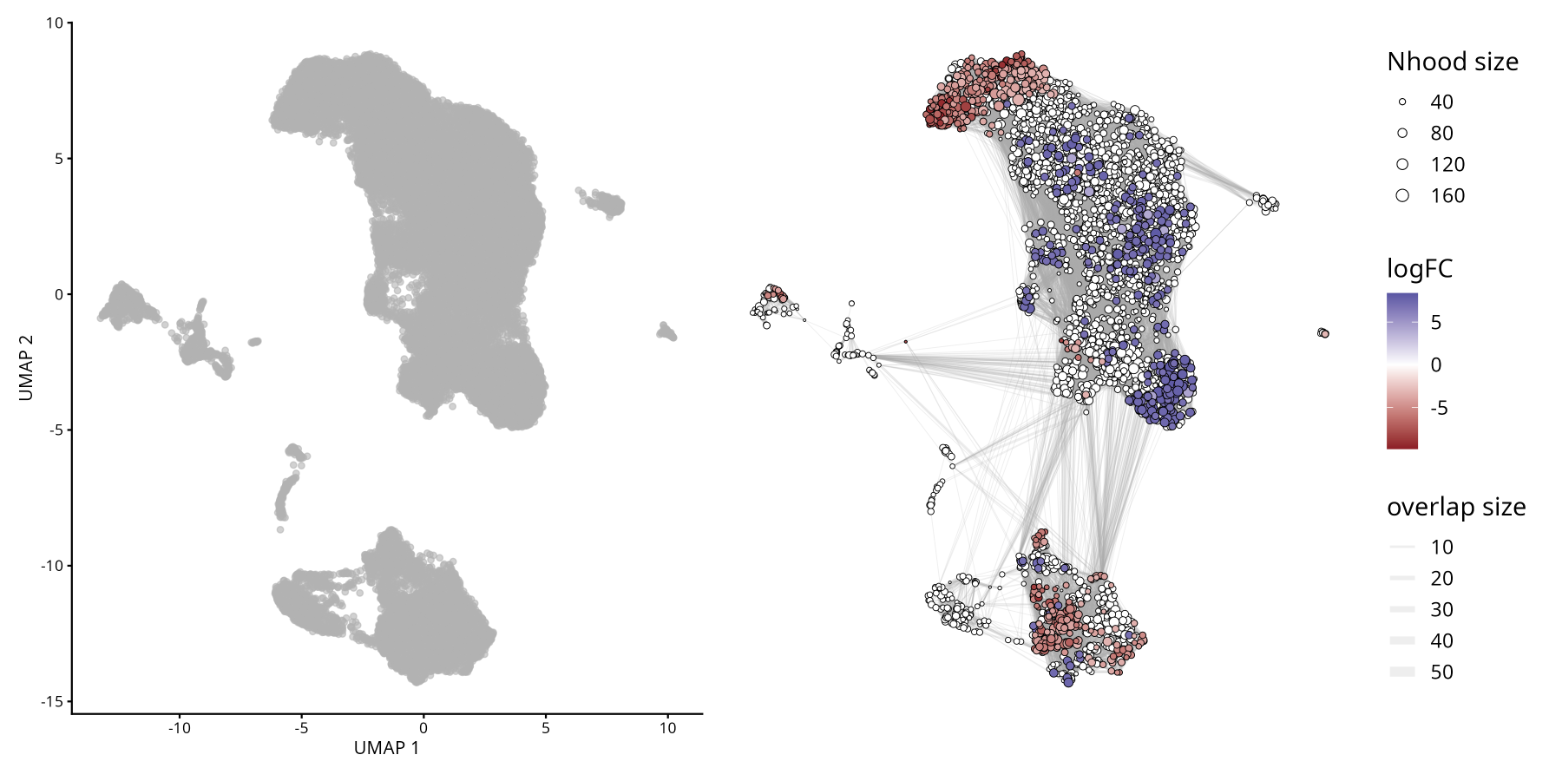

**¡No ejecutar en Colab!**

Para fines didácticos, en este paso descargaremos otras muestras de nuestro conjunto de datos para calcular la abundancia diferencial de células entre pacientes con COVID-19 leve y grave. Para que este tutorial no sea demasiado largo, simplificaremos algunos pasos.

Sin embargo, le recomendamos encarecidamente que siga las recomendaciones prácticas desarrolladas en el objeto SampleA para las demás muestras.

In [ ]:
# Abajo esta el código para procesar y fusionar múltiples muestras de scRNA-seq en un único objeto Seurat.
# creamos una lista para almacenar objetos Seurat individuales para cada muestra y luego los fusionamos en un único objeto Seurat.
# para crear esto, recorreremos una lista de nombres de archivo, 
# dónde vamos lee cada archivo, crear un objeto Seurat, realizar un filtrado de control de calidad 
# y almacenar el objeto Seurat en una lista.

# Un loop implica repetir un conjunto de comandos varias veces, 
# una vez para cada elemento de una lista o vector.

# Lista de archivos a procesar
files <- c(
  "GSM4339769_C141_filtered_feature_bc_matrix.h5",
  "GSM4339770_C142_filtered_feature_bc_matrix.h5",
  "GSM4339771_C143_filtered_feature_bc_matrix.h5",
  "GSM4339773_C145_filtered_feature_bc_matrix.h5"
)

# Inicializar con una lista vacía para almacenar objetos Serat
sc_list <- list()

for (i in files){
    sample_name <- strsplit(i, "_")[[1]][2] # Extraer el nombre de la muestra del nombre del archivo
    sc_data <- Read10X_h5(paste0("scRNAseq/", i)) # Cargar los datos 10 veces
    sc_seurat <- CreateSeuratObject(counts = sc_data, project=sample_name, min.cells=3, min.features=200) # Crear un objeto Seurat
    sc_seurat[["percent.mt"]] <- PercentageFeatureSet(sc_seurat, pattern="^MT-") # Calcular el porcentaje de genes mitocondriales
    sc_seurat <- subset(sc_seurat, nCount_RNA > 500 & nFeature_RNA < 7000 & percent.mt < 10) # Filtrar las celdas según los criterios de control de calidad
    sc_list[[sample_name]] <- sc_seurat # Almacenar el objeto Seurat en la lista con el nombre de la muestra como clave
}

# Unir todos los objetos Seurat de la lista en un único objeto Seurat
# x representa el primer objeto Seurat de la lista
# y representa el resto de los objetos Seurat de la lista
# add.cell.ids asigna prefijos únicos a los códigos de barras de cada celda de muestra para evitar duplicaciones

sc_merged <- merge(
x = sc_list[[1]], # muestra 1
y = c(sc_list[[2]], sc_list[[3]], sc_list[[4]]), # muestras 2, 3 y 4
add.cell.ids = names(sc_list) # Usar los nombres de las muestras como prefijos de ID de celda
)

# Mostrar las primeras filas del objeto Seurat fusionado
head(sc_merged)

In [ ]:
# Agregar una nueva columna de metadatos 'condition' basada en los identificadores de las muestras
# Una instrucción if-else se utiliza para clasificar las muestras C141 y C142 como 'mild' y otras como 'severe'
sc_merged$condition <- ifelse(grepl("^(C141|C142)", sc_merged$orig.ident), "mild", "severe")
sc_merged

# Verificar el número de células por muestra y condición
table(sc_merged$orig.ident)
table(sc_merged$condition)

In [ ]:
# Normalizar los datos y encontrar las características variables
sc_merged <- FindVariableFeatures(sc_merged, selection.method = "vst", nfeatures = 3000)

# Execute o workflow padron para visualización y clustering
sc_merged <- NormalizeData(sc_merged, verbose = FALSE)
all.genes <- rownames(sc_merged)
sc_merged <- ScaleData(sc_merged, features = all.genes, verbose = FALSE)
sc_merged <- RunPCA(sc_merged, features = VariableFeatures(sc_merged), verbose = FALSE)
sc_merged <- FindNeighbors(sc_merged, dims=1:30, verbose = FALSE)
sc_merged <- FindClusters(sc_merged, resolution=0.8, verbose = FALSE)

# Execute UMAP para reducir la dimensionalidad
sc_merged <- RunUMAP(sc_merged, dims=1:30, verbose = FALSE)

Se utilizó Harmony para corregir los efectos de lote mediante la columna de metadatos `orig.ident`. Esta herramienta permite la integración de múltiples conjuntos de datos y elimina eficazmente los efectos de lote en el análisis de secuenciación de ARN de una sola célula. Para una descripción detallada de las estrategias de integración, consulte el **Módulo 05**.

> Puede encontrar más información sobre Harmony en el portal oficial del Instituto Broad: [Harmony](https://portals.broadinstitute.org/harmony/)

In [ ]:
# Unir capas antes de ejecutar la integración de Harmony
sc_merged[["RNA"]] <- JoinLayers(sc_merged[["RNA"]], verbose = FALSE)

# Ejecutar Harmony para integrar muestras y corregir los efectos del lote
sc_merged <- harmony::RunHarmony(sc_merged,
                                "orig.ident", # Corregir los efectos del lote según la columna 'orig.ident'
                                reduction.save = "pca", # Guardar la nueva reducción de PCA
                                verbose = FALSE)

# Encontrar vecinos según el PCA de Harmony
sc_merged <- FindNeighbors(sc_merged, dims = 1:30, verbose = FALSE)

# Encontrar clústeres con una resolución de 0.8
sc_merged <- FindClusters(sc_merged,resolution = 0.8, verbose = FALSE)

# Ejecutar UMAP en Harmony embeddings
sc_merged <- RunUMAP(sc_merged, dims = 1:30, verbose = FALSE)

In [ ]:
# Dimplot con coloreado por clústeres y muestras
DimPlot(
  sc_merged,
  group.by = c("seurat_clusters", "orig.ident")
)

#ggsave("UMAP_COVID19_Clusters_Samples.png", width = 10, height = 5, bg = 'white')

In [ ]:
# Descaregar el paquete miloR
library(miloR)
# Convertir el objeto Seurat a SingleCellExperiment
sce <- as.SingleCellExperiment(sc_merged)

# Crear el objeto Milo a partir del objeto SingleCellExperiment
milo <- miloR::Milo(sce)
milo

In [ ]:
# Construir un grafo kNN para el objeto milo
milo <- buildGraph(milo,
                   k = 20, # número de vecinos para el grafo kNN
                   d = 30, # número de dimensiones a utilizar
                   reduced.dim = "PCA") # Reducción dimensional a utilizar

In [ ]:
# Define la vecindad del objeto milo
milo <- makeNhoods(milo,
                   prop = 0.1, # proporción de celdas a incluir en cada vecindad
                   knn = 20, # número de vecinos para el grafo kNN
                   d = 30, # número de dimensiones a usar
                   refined = TRUE) # si se refinan las vecindades

In [ ]:
# Crear un histograma de tamaños de vecindarios
plot hoodSizeHist(milo)

In [ ]:
# Contar las celulas en cada vecindario, agregando metadatos del objeto Serial original
milo <- countCells(milo, meta.data = as.data.frame(colData(milo)),
                   sample = "orig.ident") # Especifica la columna de metadatos que se usará como muestra

# Mostrar las primeras filas del recuento de celdas por vecindario
head(nhoodCounts(milo))

In [ ]:
# Crea diseño data frame para la prueba de abundancia diferencial
# El diseño data frame contiene los identificadores de muestra y sus condiciones correspondientes
# y selecciona las columnas relevantes
milo_design <- data.frame(colData(milo))[,c("orig.ident", "condition")]

# Convierte la columna "condition" en un factor,
# estableciendo "mild" como nivel de referencia
milo_design$condition <- factor(milo_design$condition, levels = c("mild", "severe")) 

# Elimina filas duplicadas para asegurar pares muestra-condición únicos
milo_design <- dplyr::distinct(milo_design)

# Establece los nombres de fila con los identificadores de muestra originales
rownames(milo_design) <- milo_design$orig.ident

# Devuelve el marco de datos milo_design
milo_design

In [ ]:
# Realizar una prueba de abundancia diferencial con milo
milo <- calcNhoodDistance(milo,
                          d=30) # Calcula la distancia entre vecindarios

In [ ]:
# Asegurar que los nombres de las filas coincidan con los identificadores de muestra en el objeto milo
rownames(milo_design) <- milo_design$orig.ident

# Prueba de abundancia diferencial
da_results <- testNhoods(milo, design = ~ condition, design.df = milo_design)

# Mostrar las primeras filas de los resultados de la prueba de abundancia diferencial
da_results %>%
    arrange(- SpatialFDR) %>%
    head()

In [ ]:
# Construir el grafo de vecindad para el objeto milo
milo <- buildNhoodGraph(milo)

# Crear un gráfico UMAP del objeto milo con los resultados de la prueba de abundancia diferencial superpuestos
plotUMAP(milo) +
plotNhoodGraphDA(milo, da_results,
                 alpha=0.05) + 
                 plot_layout(guides="collect")

#ggsave("plotUMAP_with_DA_results.png", plot = last_plot(), width = 8, height = 6, bg = 'white')

Comprensión de los términos clave en el análisis de abundancia diferencial

* Fold Change (FC): Representa la magnitud de la diferencia en abundancia entre condiciones o grupos. En este contexto, la CF indica cuánto se enriquece o reduce una población celular dada al comparar las condiciones experimentales.

* Tasa de falsos descubrimientos ((False Discovery Rate/FDR): Corrección estadística aplicada a los valores p para tener en cuenta múltiples pruebas. Ayuda a controlar la proporción de falsos positivos, lo que garantiza que los resultados significativos sean más fiables.

* Clúster: Se refiere a un grupo de células identificado mediante métodos de agrupamiento no supervisados. Cada clúster representa una población con perfiles de expresión génica similares, y el análisis de abundancia diferencial analiza si la frecuencia de estos clústeres cambia entre condiciones.

En conjunto, estas métricas nos permiten interpretar si poblaciones celulares específicas se expanden o reducen significativamente, manteniendo el rigor estadístico y la relevancia biológica.

# Análisis de enriquecimiento de términos GO

El análisis de enriquecimiento es una herramienta poderosa para extraer información biológicamente relevante de los conjuntos de datos de células únicas, facilitando el descubrimiento de genes clave, vías y procesos celulares. En scRNA-seq, los investigadores suelen tratar con tejidos complejos compuestos por varios tipos celulares. Este análisis puede revelar nuevos conocimientos biológicos al resaltar asociaciones inesperadas entre conjuntos de genes y términos de la Ontología Génica (GO, por sus siglas en inglés, Gene Ontology), proporcionando una comprensión más profunda de las funciones celulares y los mecanismos de enfermedades.

El Análisis de Enriquecimiento GO es un método utilizado para identificar términos GO sobrerrepresentados dentro de un conjunto de genes. Este análisis ayuda a determinar si ciertos procesos biológicos, funciones moleculares o componentes celulares están significativamente asociados con los genes de interés.

La Ontología Génica (GO) es un sistema integral que categoriza los genes en categorías jerárquicas según:

* Procesos Biológicos (BP): Los objetivos biológicos a los que el gen contribuye, como el ciclo celular, la apoptosis o el metabolismo.

* Funciones Moleculares (MF): Las actividades moleculares realizadas por el producto génico, como la unión o la actividad catalítica.

* Componentes Celulares (CC): El lugar dentro de la célula donde el producto génico está activo, como el núcleo o el mitocondrion.

Además, los genes se referencian comúnmente mediante identificadores estandarizados:

* Gene Symbol: Una abreviatura corta y legible (p. ej., TP53, ACTB) que representa el nombre del gen.

* EntrezID: Un identificador numérico único asignado por la base de datos Entrez Gene del NCBI, que garantiza la coherencia entre conjuntos de datos y herramientas.

In [ ]:
# Filtrado de genes

my.genes = sampleA.markers %>%
  filter(abs(avg_log2FC) > 1,  # Esta condición retiene las filas donde el valor absoluto del cambio promedio en log2 es mayor a 1
         p_val_adj < 0.10) %>% # Esta condición retiene las filas donde el valor p ajustado es menor a 0.10
  dplyr::select(gene) %>%      # La función select del paquete dplyr se usa para seleccionar la columna de genes de los datos filtrados.
  pull() # La función pull extrae los valores de la columna seleccionada de genes como un vector

# Mostrar las primeras filas
head(my.genes)

In [ ]:
nrow(sampleA.markers) # Esta función entrega el número de filas
genes <- sampleA.markers %>% arrange(desc(avg_log2FC)) # Ordenar los datos en orden descendente basado en la columna que indica el promedio de cambio en log2.

# Mostrar las primeras filas
head(genes)

In [ ]:
library(clusterProfiler) # Proporciona funciones para la clasificación de términos biológicos y el análisis de enriquecimiento.

# Convertir identificadores de genes
my.map = bitr(my.genes, # Esta función convierte los identificadores de genes de un tipo a otro
              fromType="SYMBOL", # Especifica que los identificadores de genes de entrada son símbolos de genes
              toType="ENTREZID", # Especifica que la salida debe ser en formato Entrez ID
              OrgDb="org.Hs.eg.db") # Especifica la base de datos de organismos para genes humanos

# Mostrar las primeras entradas
head(my.map)

# Calcular el número de genes no mapeados
length(my.genes) - nrow(my.map)

### Clasificación por términos GO

In [ ]:
# Subontologías: Biological Process (BP; procesos biológicos), Molecular Function (MF; función molecular), Cellular Component (CC; componente celular)
library(org.Hs.eg.db) # Librería que contiene anotaciones para genes humanos.
# Agrupa los genes en función de sus términos GO
ggo_bp = groupGO(gene     = my.map$ENTREZID, # Especifica la lista de ID de genes ENTREZ para agrupar
                 OrgDb    = org.Hs.eg.db, 
                 ont      = "BP", # Especifica que el agrupamiento GO debe basarse en la subontología de "Proceso Biológico".
                 readable = TRUE) # Convierte los IDs de Entrez a símbolos de genes para una interpretación más fácil.

# Muestra las primeras entradas del objeto ggo_bp
head(ggo_bp)

In [ ]:
# Subontologías: BP, MF, CC
ggo_mf = groupGO(gene = my.map$ENTREZID, # Especificar los genes de EntrezID para agrupar
                 OrgDb    = org.Hs.eg.db, # Especificar la base de datos de organismos para genes humanos
                 ont      = "MF", # Especificar la ontología GO como Función Molecular (MF)
                 readable = TRUE) # Convertir los ID de los genes de Entrez de nuevo a símbolos genéticos legibles

# Mostrar las primeras entradas del objeto ggo_mf
head(ggo_mf)

In [ ]:
# Subontologias: BP, MF, CC
ggo_cc = groupGO(gene = my.map$ENTREZID, # Especificar los genes de EntrezID para agrupar
                 OrgDb   = org.Hs.eg.db, # Especificar la base de datos de organismos para genes humanos
                 ont      = "CC", # Especificar la ontología GO como Componente Celular (CC)
                 readable = TRUE) # Convertir los ID de los genes de Entrez de nuevo a símbolos genéticos legibles

# Muestra las primeras pocas entradas del objeto ggo_cc
head(ggo_cc)

### Análisis de sobrerepresentación de términos GO

In [ ]:
# Esta función realiza el análisis de enriquecimiento de términos GO en un set de genes dado.
ego <- enrichGO(gene          = my.map$ENTREZID, # Especificar los genes de EntrezID para agrupar
                OrgDb         = org.Hs.eg.db,  # Especificar la base de datos de organismos para genes humanos
                ont           = "BP", # Especificar la ontología GO como Proceso Biológico (BP)
                pAdjustMethod = "BH", # El método utilizado para ajustar los valores p para controlar el FDR de Benjamini-Hochberg (BH)
                pvalueCutoff  = 0.01, # El umbral de valor p para significancia
                qvalueCutoff  = 0.05, # El umbral de valor q para significancia
                readable      = TRUE)
head(ego)

## Enriquecimiento de Ontología Génica en Otros Organismos

Es importante destacar que el análisis de enriquecimiento de vías metabólicas no se limita a modelos humanos o animales. Para organismos no modelo y plantas, existe una amplia gama de bases de datos especializadas y anotaciones funcionales, lo que permite una interpretación robusta de los datos transcriptómicos en diversas especies.

En la investigación vegetal, los análisis de enriquecimiento generalmente se basan en repositorios de vías metabólicas específicas de cada planta y anotaciones de Ontología Génica (OG) adaptadas a especies como *Arabidopsis thaliana*, arroz y maíz. Estos recursos son esenciales para investigar procesos biológicos importantes, como el desarrollo vegetal, las respuestas al estrés e inmunitarias, la señalización hormonal y las adaptaciones metabólicas a los estímulos ambientales.

Desde un punto de vista técnico, cualquier tipo de identificador génico compatible con un objeto `OrgDb` apropiado puede utilizarse directamente en análisis basados ​​en OG dentro del ecosistema Bioconductor. Esta flexibilidad permite una anotación funcional continua en múltiples organismos y sistemas de identificación.

Varias bases de datos de vías han seleccionado recursos que amplían el alcance de los análisis de enriquecimiento entre taxones.

* El [WikiPathways](https://www.wikipathways.org/) es una plataforma abierta y colaborativa dedicada a la selección de vías, que ofrece una amplia cobertura de organismos, desde vertebrados hasta bacterias y plantas. Al adoptar un modelo de selección colaborativa, WikiPathways complementa recursos ya consolidados como `KEGG`, `Reactome` y `Pathway Commons`.

* En el contexto de la biología vegetal, [Plant Reactome](https://plantreactome.gramene.org/) ofrece una base de datos de vías, de código abierto y pública, seleccionada manualmente y revisada por pares, que abarca más de 100 especies de plantas.

* - Para organismos que no cuentan con un paquete `OrgDb` dedicado en Bioconductor (p. ej., especies sin una base de datos de anotaciones disponible, similar a `org.Mm.eg.db` en ratones).

- Los usuarios pueden recuperar anotaciones específicas de cada organismo, cuando estén disponibles, a través de recursos en línea como [AnnotationHub](https://www.bioconductor.org/packages/release/bioc/html/AnnotationHub.html), lo que garantiza que los análisis de enriquecimiento permanezcan accesibles incluso para especies menos caracterizadas.

# Correccion de ARN Ambiental (Opcional)


En algunos casos puede existir sospecha de que los datos presenten contaminacion desde celulas que se destruyeron y liberaron su contenido al medio en el momento de preparar las librerias, lo que podria alterar las cuentas de ARNs en las celulas integras. Herramientas como SoupX se encargan de analizar los barcodes que se detectaron como background y su contenidos de ARNs, con la finalidad de identificar transcritos potencialmente incrementados por contaminacion en los barcodes detectados como celulas y corregir su efecto.

> Consulte el artículo original [SoupX removes ambient RNA contamination from droplet-based single-cell RNA sequencing data](https://pubmed.ncbi.nlm.nih.gov/33367645/)

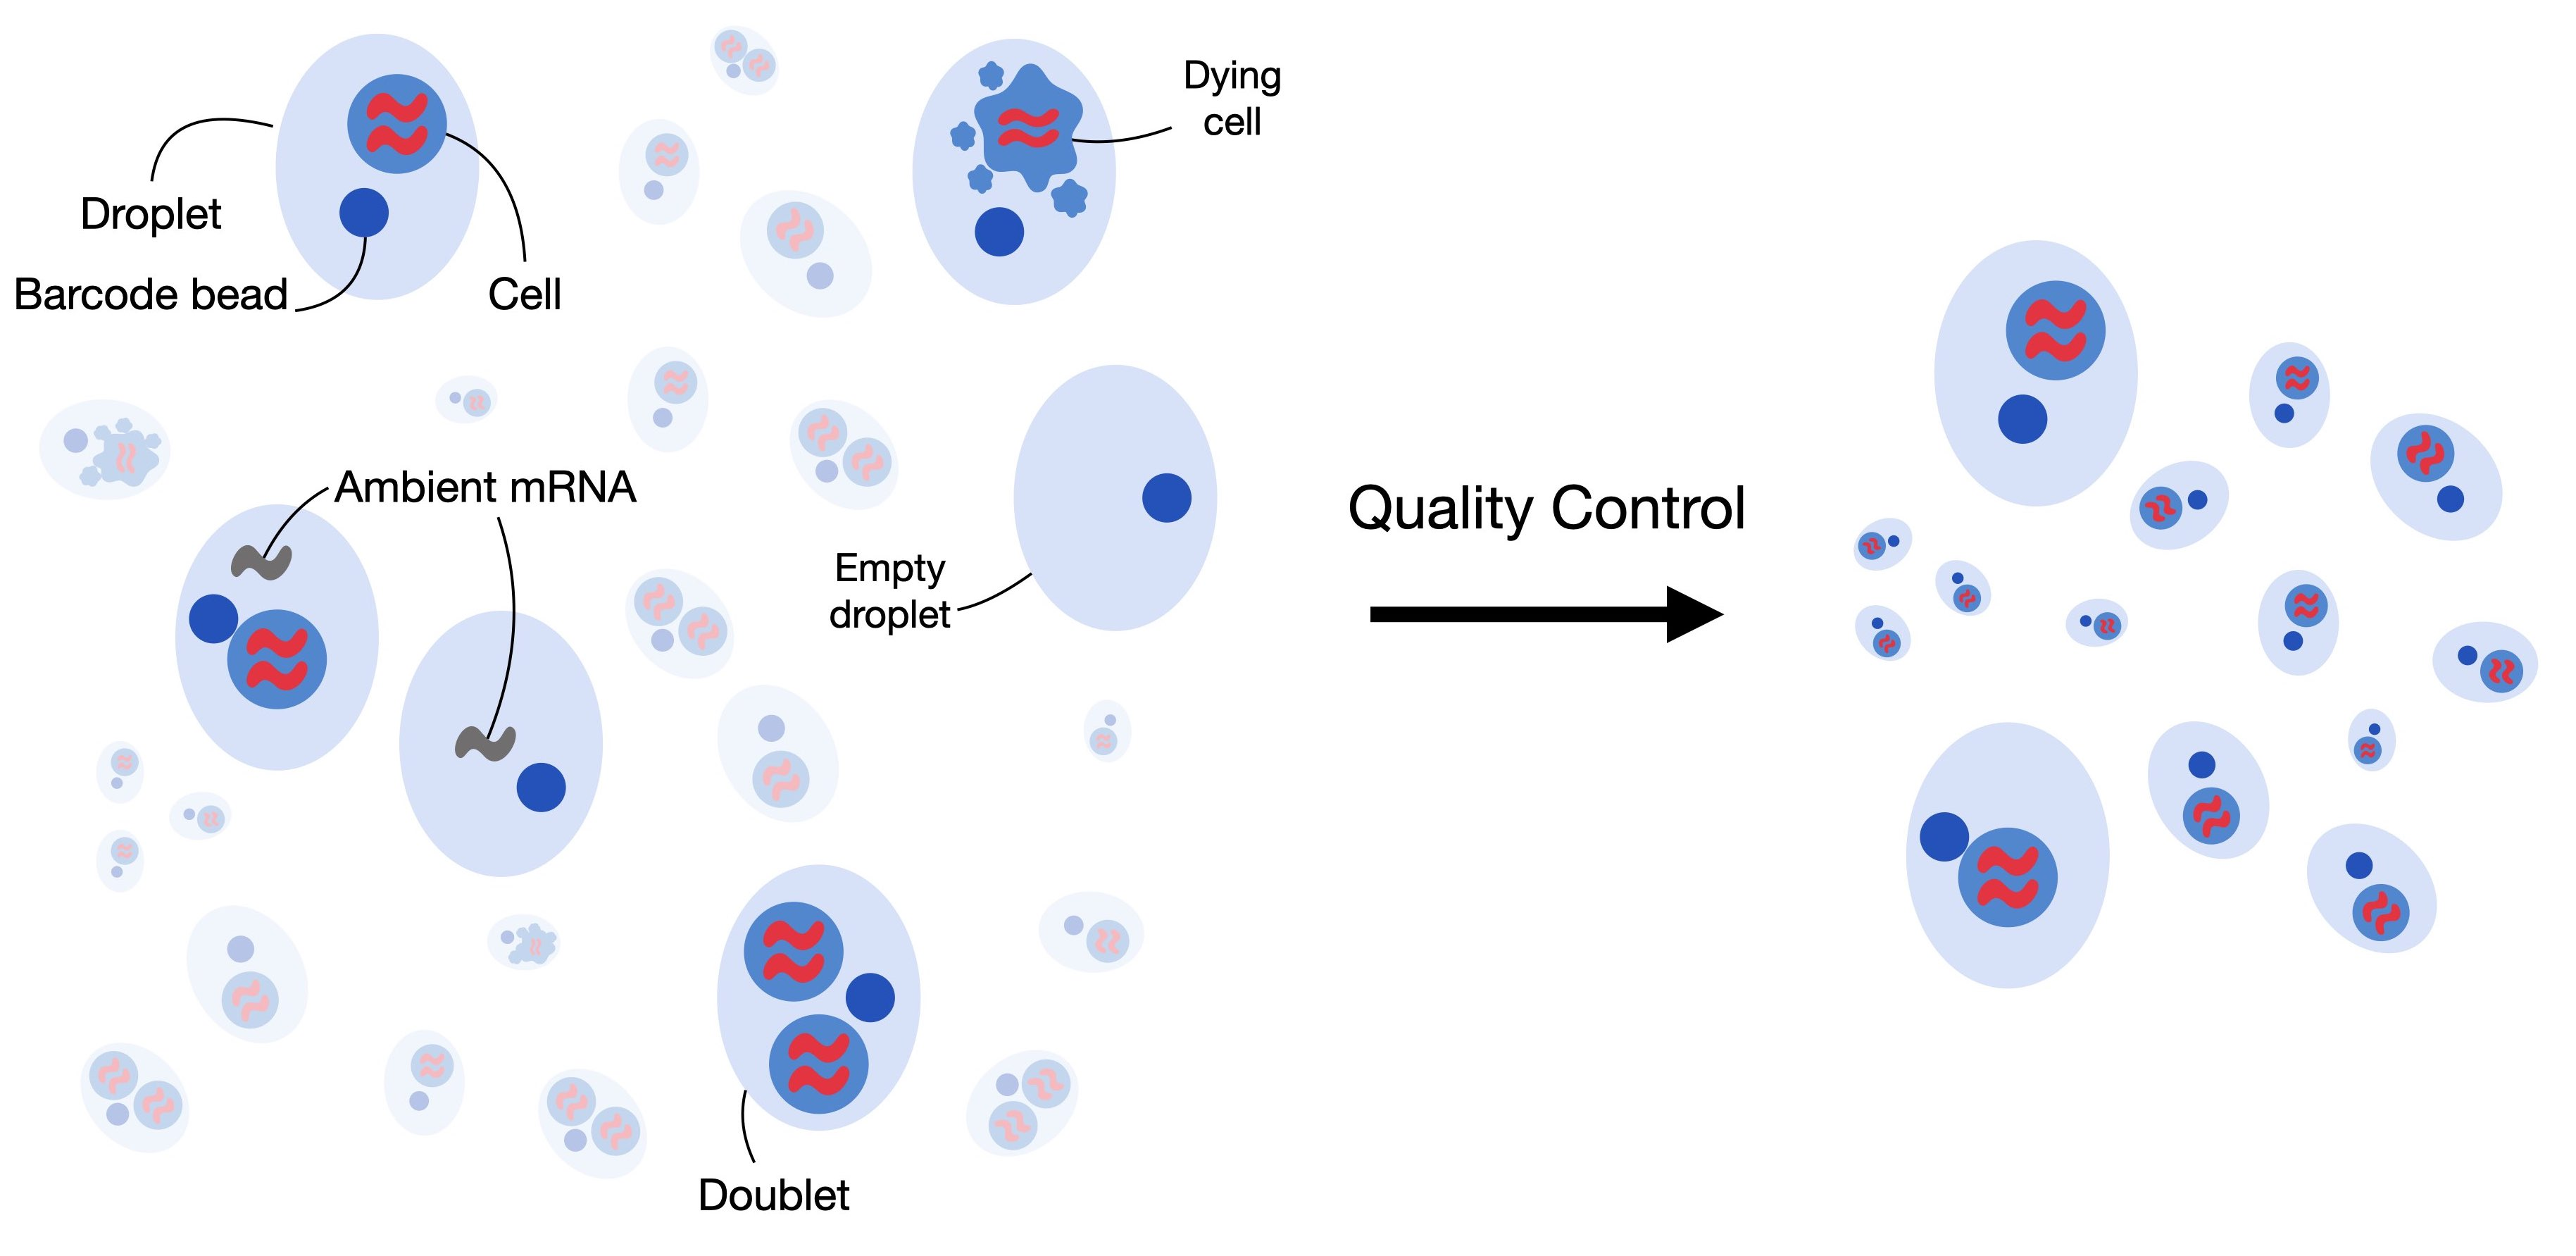

Obtenido de https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html

Para demostrar la simplicidad de este proceso, utilizaremos un conjunto de datos generado con tecnología 10x y mapeado con CellRanger (v8.0.1). Estos datos corresponden a una muestra de un estudio sobre cáncer de cabeza y cuello.

> Conjunto de datos disponible en NCBI/SRA: https://www.ncbi.nlm.nih.gov/sra/?term=SRR10340945.

> Artículo original: [B cell signatures and tertiary lymphoid structures contribute to outcome in head and neck squamous cell carcinoma](https://pmc.ncbi.nlm.nih.gov/articles/PMC8184766/)

In [ ]:
download.file("https://github.com/integrativebioinformatics/scNotebooks/blob/main/scNotebooks-Resources/SRR10340945-Cellranger_outs_Folder.tar.gz","SRR10340945-Cellranger_outs_Folder.tar.gz")
shell_call("tar -xvzf SRR10340945-Cellranger_outs_Folder.tar.gz")
shell_call("ls -lh")

Como se puede observar en el siguiente codigo, para datos de 10x el proceso es tan simple como cargar la carpeta de resultados de obtenidad desde cellranger y ejecutar la funcion `autoEstCont()`.

In [ ]:
# Cargar las librerías necesarias
library(SoupX)
library(DropletUtils)

# Definir una semilla para la reproducibilidad
set.seed(123)

# Cargar los datos de 10X desde la carpeta especificada
sc = load10X("Mapped_SRR10340945/outs/")

# Executar la estimación automática de la contaminación
#png("SoupX_SRR10340945.png", width = 1080, height = 1080)
sc = autoEstCont(sc)
#dev.off()

In [ ]:
# Separar la fracción de contaminación estimada
rhoEst <- sc$fit$rhoEst

# Fraccion de contaminacion estimada pelo SoupX
print(rhoEst) 

# Normalmente las cuentas usan numeros enteros, 
# para compatibilidad posterior con otras herramientas aqui se redondea.
out = adjustCounts(sc, roundToInt = TRUE) 

# Para exportar los datos en una carpeta en el formato de los resultados de cellranger
DropletUtils:::write10xCounts("./SRR10340945_clean",out) 

In [ ]:
shell_call("ls -lh SRR10340945_clean")

Para datos en los que no se tenga acceso a la carpeta de salida de cellranger completa ("outs") o no sean generados con tecnologia de 10x, tambien se puede emplear SoupX implementando una serie de pasos alternativos, que involucran generar un clustering, dado que en la manera anterior, se utiliza el clustering generado por cellranger cuya informacion esta disponible en la carpeta "outs", ademas de las matrices de cuentas. 

En las siguientes lineas de codigo veras un ejemplo adaptado desde https://cellgeni.github.io/notebooks/html/new-10kPBMC-SoupX.html con los datos que recien empleamos. 

Lo indispensable es tener ambas matrices: matriz de cuentas filtradas y matriz de cuentas brutas.

In [ ]:
filt.matrix <- Read10X_h5("Mapped_SRR10340945/outs/SRR10340945.filtered_feature_bc_matrix.h5",use.names = T)
raw.matrix  <- Read10X_h5("Mapped_SRR10340945/outs/SRR10340945.raw_feature_bc_matrix.h5",use.names = T)
srat  <- CreateSeuratObject(counts = filt.matrix)

# crear el objeto SoupChannel usando las matrices crudas y filtradas
soup.channel  <- SoupChannel(raw.matrix, filt.matrix)
soup.channel

Ahora ejecutaremos los pasos de normalizacion hasta la clusterizacion requerida por SoupX, por simplicidad y rapidez utilizamos `NormalizeData()`, pero puedes reemplazar por `SCTransform()` como se implementaba en el tutorial que adaptamos si asi lo prefieres

In [ ]:
srat    <- NormalizeData(srat, verbose = F)
srat    <- FindVariableFeatures(srat, verbose = F)
srat    <- ScaleData(srat, verbose = F)
srat    <- RunPCA(srat, verbose = F)
srat    <- RunUMAP(srat, dims = 1:30, verbose = F)
srat    <- FindNeighbors(srat, dims = 1:30, verbose = F)
srat    <- FindClusters(srat, verbose = T)

Luego integramos la informacion obtenida desde el procesamiento con Seurat al objeto SoupChannel antes definido

In [ ]:
meta <- srat@meta.data
umap <- srat@reductions$umap@cell.embeddings

# Define las identidades de clúster y coordenadas UMAP en el objeto SoupChannel
soup.channel <- setClusters(soup.channel,
setNames(meta$seurat_clusters, rownames(meta)))

# Define coordenadas UMAP en el objeto SoupChannel
soup.channel <- setDR(soup.channel, umap)

Finalmente ya podremos estimar la contaminacion y guardar nuestros datos corregidos

In [ ]:
soup.channel <- autoEstCont(soup.channel)

# Recuento ajustado después de la eliminación de la contaminación
adj.matrix <- adjustCounts(soup.channel, roundToInt = T)

# Salvar la matriz ajustada en formato 10X
DropletUtils:::write10xCounts("SRR10340945_cleanV2", adj.matrix)

> Otras herramientas con las que se puede implementar este proceso de corrección de RNA ambiental y de las que puedes buscar mas informacion si estas interesado son [DecontX](https://pmc.ncbi.nlm.nih.gov/articles/PMC7059395/) y [CellBender](https://www.nature.com/articles/s41592-023-01943-7)